# Retail Sales Forecasting Case Study

## Executive Summary

### Business Problem

A retail chain wants to forecast weekly sales for each Store–Department combination to improve inventory planning, staffing allocation, and promotional decision-making.

### Objective

Develop an end-to-end forecasting pipeline using statistical and machine learning approaches to accurately predict weekly sales.

### Approach
Built and compared statistical models (ARIMA, SARIMA) on aggregated
company-wide weekly sales, and ML models (Linear Regression, Decision Tree, Random
Forest, XGBoost) at full store-department-week granularity, using lag/rolling
features and a strict date-based train/test split to avoid data leakage.

### Models Evaluated

- ARIMA
- SARIMA
- Linear Regression
- Decision Tree
- Random Forest
- XGBoost

### Best Model
Random Forest at the store-department level
(MAE ≈ $1,226, WMAE ≈ $1,280, R² = 0.987). SARIMA performed strongly for
aggregate company-wide trend forecasting (MAPE ≈ 2.67%).

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, statistical forecasting, machine learning, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

## Reusable Evaluation Functions

The Linear Regression, Decision Tree, Random Forest, and XGBoost sections below all need the same
three things: printed metrics (MAE/RMSE/MAPE/R²), an actual-vs-predicted scatter plot, and residual
diagnostics (residual-vs-predicted + residual distribution). These are defined once here and reused
in every model section instead of being retyped four times, and are used again later for feature
importance and the final model comparison.


In [2]:
def evaluate_regression(y_true, y_pred, model_name):
    """Compute and print standard regression metrics for one model's test predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    mean_actual = np.mean(y_true)

    print(f"--- {model_name} ---")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Percent RMSE: {rmse/mean_actual*100:.2f}%")
    print(f"Percent MAE : {mae/mean_actual*100:.2f}%")
    print(f"R²  : {r2:.4f}")

    return {
        'Model': model_name,
        'MAE': mae, 'Percent_MAE': mae/mean_actual*100,
        'RMSE': rmse, 'Percent_RMSE': rmse/mean_actual*100,
        'MAPE': mape, 'R2': r2
    }


def plot_actual_vs_predicted(y_true, y_pred, model_name):
    """Scatter of actual vs. predicted sales, with a perfect-prediction reference line."""
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()


def plot_residual_diagnostics(y_true, y_pred, model_name):
    """Residuals-vs-predicted (bias check) and residual distribution, side by side."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred, residuals)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel("Predicted Sales")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"{model_name} Residual Plot")

    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].set_title(f"{model_name}: Distribution of Residuals")

    plt.tight_layout()
    plt.show()
    return residuals


def get_feature_importance(model, feature_names, model_name, top_n=5):
    """Return and print a fitted tree-based model's top feature importances."""
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)
    print(f"--- {model_name}: top {top_n} features ---")
    print(importance.head(top_n))
    return importance


## Data Understanding

In [3]:
df=pd.read_csv('Time Series Analysis/clean_data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420212 entries, 0 to 420211
Data columns (total 24 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    420212 non-null  int64  
 1   Store         420212 non-null  int64  
 2   Dept          420212 non-null  int64  
 3   Date          420212 non-null  object 
 4   Weekly_Sales  420212 non-null  float64
 5   IsHoliday     420212 non-null  bool   
 6   Temperature   420212 non-null  float64
 7   Fuel_Price    420212 non-null  float64
 8   MarkDown1     420212 non-null  float64
 9   MarkDown2     420212 non-null  float64
 10  MarkDown3     420212 non-null  float64
 11  MarkDown4     420212 non-null  float64
 12  MarkDown5     420212 non-null  float64
 13  CPI           420212 non-null  float64
 14  Unemployment  420212 non-null  float64
 15  Type          420212 non-null  object 
 16  Size          420212 non-null  int64  
 17  Super_Bowl    420212 non-null  bool   
 18  Labo

In [5]:
df.isnull().sum()

Unnamed: 0      0
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
Super_Bowl      0
Labor_Day       0
Thanksgiving    0
Christmas       0
week            0
month           0
year            0
dtype: int64

Data was arrived pre-cleaned with no missing values; MarkDown nulls likely already imputed as 0 by a prior process.

In [6]:
df.duplicated().sum() # Zero duplicates

0

In [7]:
print("Duplicate Store-Dept-Date combos:", df.duplicated(subset=['Store', 'Dept', 'Date']).sum())

Duplicate Store-Dept-Date combos: 0


Zero duplicates were found

In [103]:
df.describe(include='number')

,Unnamed: 0,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,week,month,year,Weekly_Sales_log,quarter,lag_1,lag_2,lag_4,lag_52,rolling_mean_4,rolling_std_4
count,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,420212.000000,416889.000000,413606.000000,407117.000000,260298.000000,407117.000000,407117.000000
mean,210734.273000,22.195611,44.241309,16033.114591,60.090599,3.360890,2590.323565,878.905242,468.845949,1083.534361,1662.805002,171.212496,7.960000,136749.732787,25.828408,6.449866,2010.968454,8.528536,2.482968,16051.602449,16069.836845,16095.757820,16272.849387,16086.946229,1981.675118
std,121717.137345,12.787236,30.508819,22729.492116,18.447857,0.458519,6053.415601,5076.928566,5534.069859,3896.068938,4206.209357,39.162445,1.863879,60993.084568,14.152489,3.243397,0.796898,2.020668,1.071469,22745.431959,22759.687332,22772.757871,22551.533630,22247.469686,5151.030034
min,0.000000,1.000000,1.000000,0.010000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,1.000000,1.000000,2010.000000,0.009950,1.000000,0.010000,0.010000,0.010000,0.010000,0.015000,0.000000
25%,105304.750000,11.000000,18.000000,2120.130000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,14.000000,4.000000,2010.000000,7.659704,2.000000,2131.080000,2141.535000,2158.710000,2424.800000,2219.910000,273.148355
50%,210770.500000,22.000000,37.000000,7661.700000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.350989,7.866000,140167.000000,26.000000,6.000000,2011.000000,8.944120,2.000000,7678.690000,7694.145000,7716.850000,8047.275000,7821.635000,763.990504
75%,316112.250000,33.000000,74.000000,20271.265000,74.280000,3.738000,2809.050000,2.400000,4.540000,425.290000,2168.040000,212.445487,8.567000,202505.000000,38.000000,9.000000,2012.000000,9.917009,3.000000,20291.810000,20314.340000,20353.690000,20580.622500,20433.255000,1938.249746
max,421569.000000,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,52.000000,12.000000,2012.000000,13.448930,4.000000,693099.360000,693099.360000,693099.360000,693099.360000,339472.757500,280480.021441


In [8]:
print("Unique stores:", df['Store'].nunique())
print("Unique departments:", df['Dept'].nunique())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Unique stores: 45
Unique departments: 81
Date range: 01-04-2011 to 31-12-2010


In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print(f'Date Range: {df['Date'].min()} to {df['Date'].max()}')
df.sort_values(['Store', 'Dept', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)


Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


### Summary

The dataset consists of **420,212 weekly sales records** collected from **45 retail stores** and **81 departments**, covering the period from **February 2010 to October 2012**.

Data quality checks confirmed that the dataset contains **no missing values** and **no duplicate records**, indicating that it is clean and ready for analysis. The **Date** column was converted to the `datetime` format and the dataset was sorted by **Store**, **Department**, and **Date** to preserve the chronological order of observations. This ordering is essential for reliable time series analysis, lag feature generation, and preventing data leakage during model development.

Overall, the dataset provides comprehensive temporal, store-level, and department-level information required for accurate retail sales forecasting.

In [10]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------#

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand the behaviour of weekly retail sales, identify temporal trends and seasonal patterns, evaluate the influence of stores, departments, holidays, and promotional activities, and examine relationships among numerical variables.

The insights obtained from this analysis guide feature engineering and the selection of appropriate forecasting models.

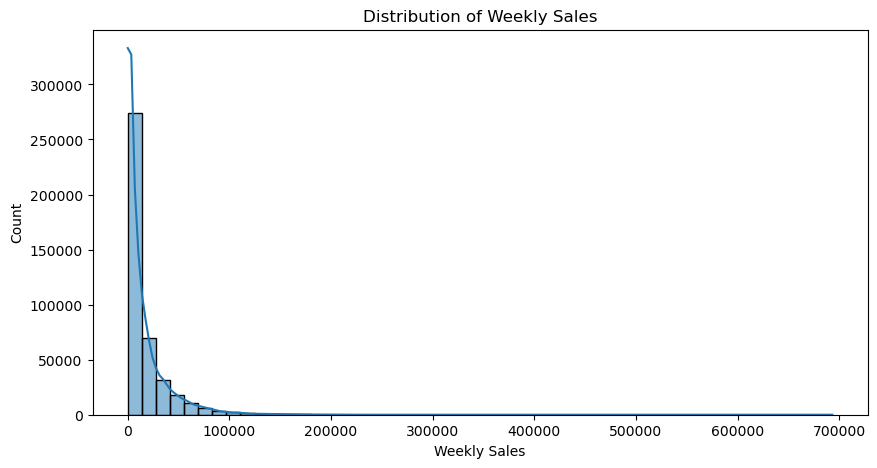

count    420212.000000
mean      16033.114591
std       22729.492116
min           0.010000
25%        2120.130000
50%        7661.700000
75%       20271.265000
max      693099.360000
Name: Weekly_Sales, dtype: float64


In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.show()

print(df["Weekly_Sales"].describe())

The weekly_sales data is right-skewed due to large outliers which are pulling the distribution towards the x-axis.

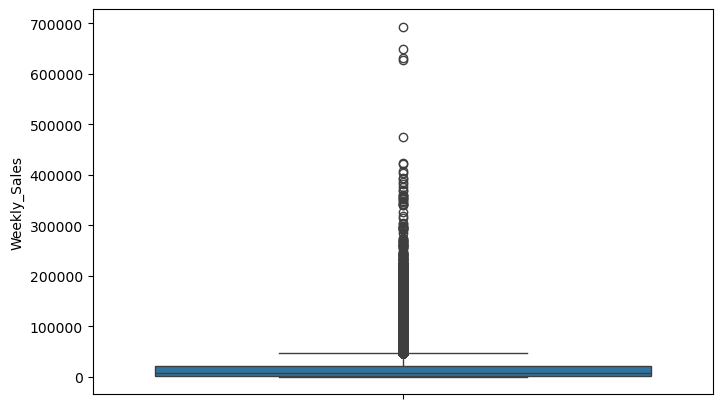

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Weekly_Sales'])
plt.show()


The weekly sales contain huge outliers with the highest of 693099.3

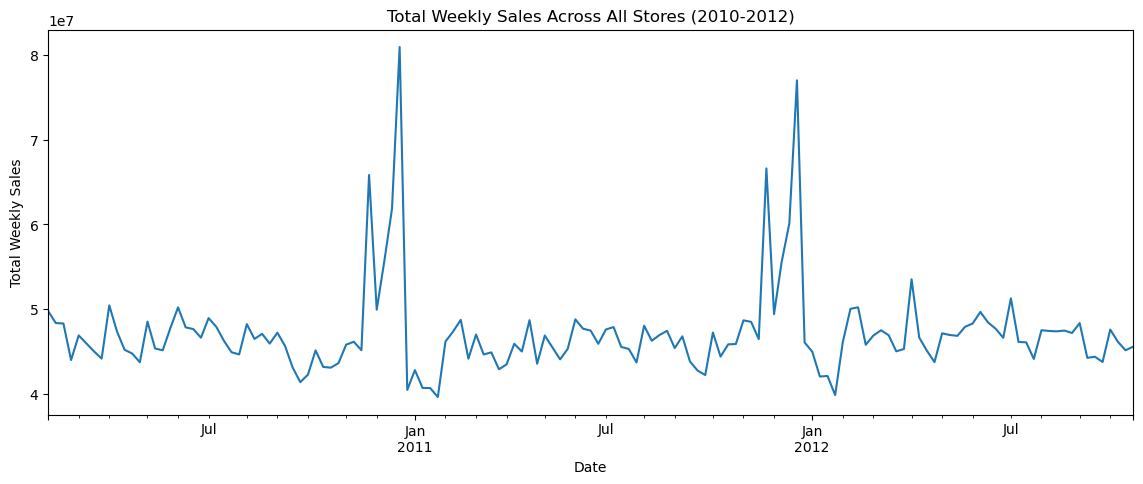

In [13]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))
weekly_total.plot()
plt.title('Total Weekly Sales Across All Stores (2010-2012)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()


- Weekly sales show clear fluctuations with recurring seasonal peaks.
- Sharp increases are observed during major shopping periods.
- Overall sales remain relatively stable with slight long-term growth.

In [14]:
print(df['Date'].dt.day_name().unique())

['Friday']


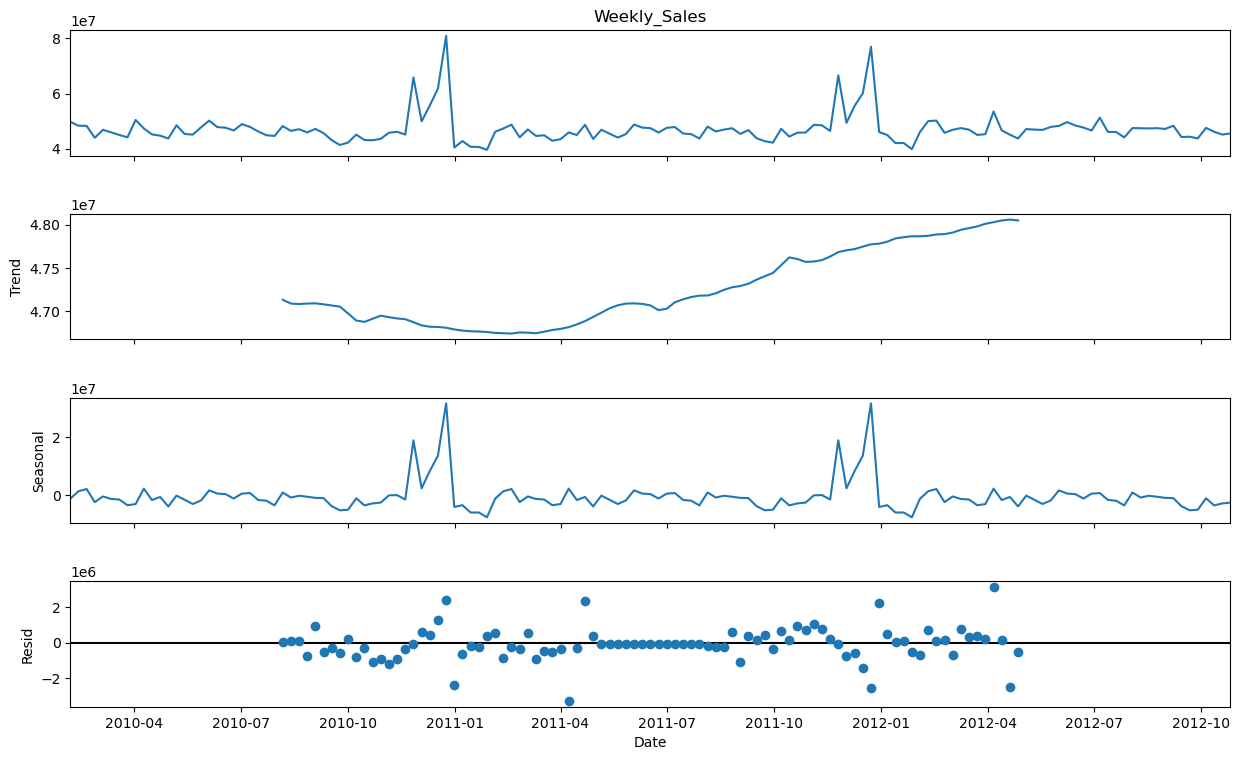

In [15]:
decomposition = seasonal_decompose(weekly_total, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.xlabel('Date')

plt.show()


- The **trend component** shows a slight decline during the early period, followed by a gradual increase in overall weekly sales from mid-2011 onwards.
- The **seasonal component** exhibits clear recurring peaks around the same period each year, confirming the presence of strong annual seasonality.
- The **residual component** is mostly centered around zero, with a few large positive and negative spikes that likely correspond to exceptional sales events not explained by the trend or seasonal pattern.

**Key Insight:** The decomposition confirms that retail sales contain both trend and strong seasonal behaviour, supporting the use of seasonal forecasting methods (SARIMA) and calendar- and lag-based features in the machine learning models.

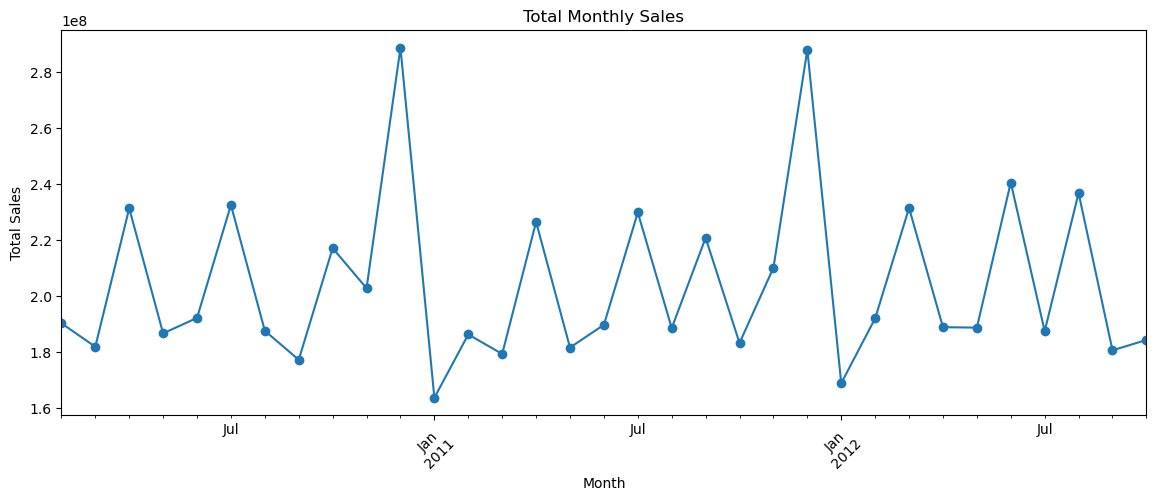

In [16]:
df['month_year'] = df['Date'].dt.to_period('M')
monthly_total = df.groupby('month_year')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))
monthly_total.plot(kind='line', marker='o')
plt.title('Total Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

- Monthly sales display recurring year-end peaks.
- Sales decline immediately after the holiday season.
- The pattern confirms annual seasonality.

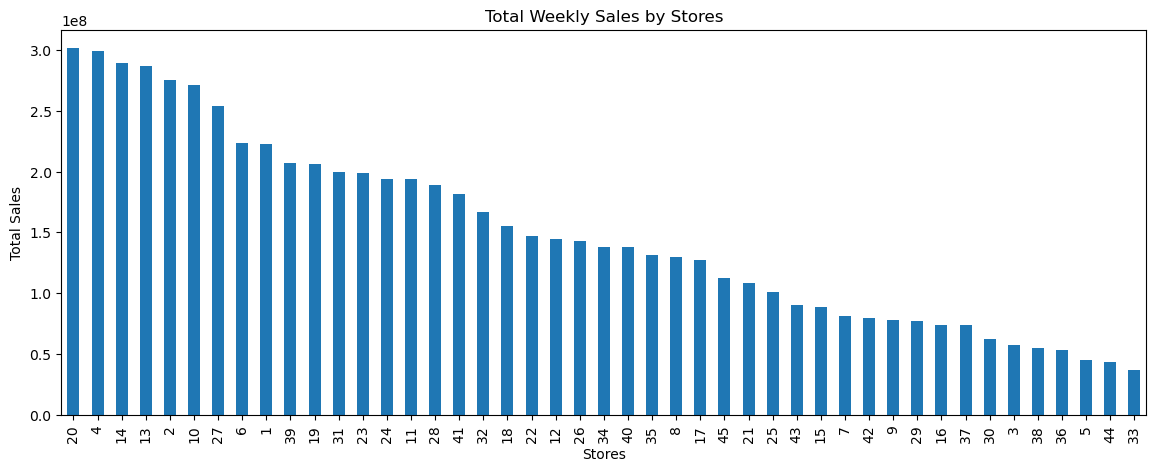

Top 5 stores:
 Store
20    3.014014e+08
4     2.995453e+08
14    2.890019e+08
13    2.865180e+08
2     2.753872e+08
Name: Weekly_Sales, dtype: float64

Bottom 5 stores:
 Store
38    55159900.70
36    53413353.10
5     45476119.71
44    43293671.55
33    37160325.40
Name: Weekly_Sales, dtype: float64


In [17]:
store_sales=df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
store_sales.plot(kind='bar')
plt.title('Total Weekly Sales by Stores')
plt.xlabel('Stores')
plt.ylabel('Total Sales')
plt.show()

print("Top 5 stores:\n", store_sales.head())
print("\nBottom 5 stores:\n", store_sales.tail())

- Sales differ substantially across stores.
- A few stores contribute a large share of total revenue.
- Store identity is likely an important predictor.

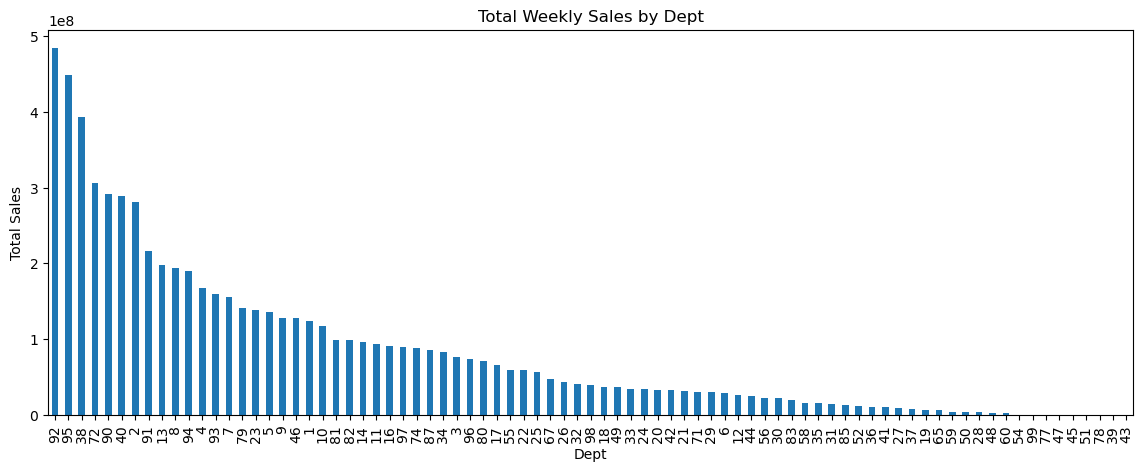

Top 5 dept:
 Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057282e+08
90    2.910685e+08
Name: Weekly_Sales, dtype: float64

Bottom 5 dept:
 Dept
45    45496.91
51    31011.35
78     2066.91
39      177.98
43       14.32
Name: Weekly_Sales, dtype: float64


In [18]:
dept_sales=df.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
dept_sales.plot(kind='bar')
plt.title('Total Weekly Sales by Dept')
plt.xlabel('Dept')
plt.ylabel('Total Sales')
plt.show()

print("Top 5 dept:\n", dept_sales.head())
print("\nBottom 5 dept:\n", dept_sales.tail())

- Customer demand varies considerably across departments.
- Some departments consistently outperform others.

      Weekly_Sales           Size
Type                             
A     20148.108162  182225.385098
B     12290.549297  101796.844232
C      9549.454168   40536.097070


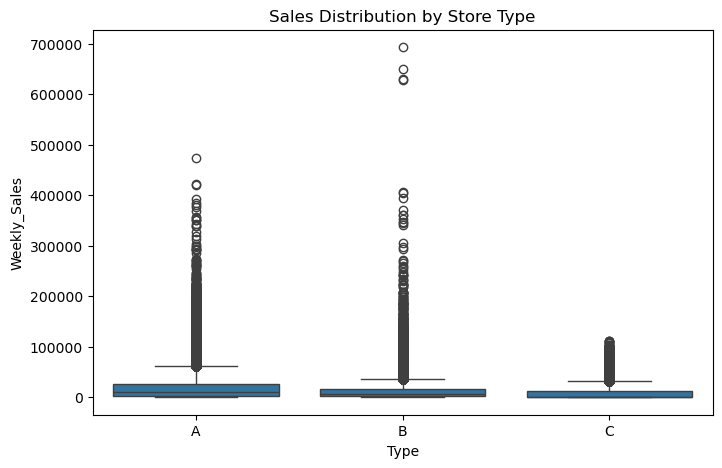

In [19]:
store_type=df.groupby('Type')[['Weekly_Sales','Size']].mean()
print(store_type)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Type', y='Weekly_Sales')
plt.title('Sales Distribution by Store Type')
plt.show()

# 

- Type A stores generate the highest average sales.
- Larger stores generally perform better.
- High-value outliers occur across all store types.

<Axes: xlabel='Size', ylabel='Weekly_Sales'>

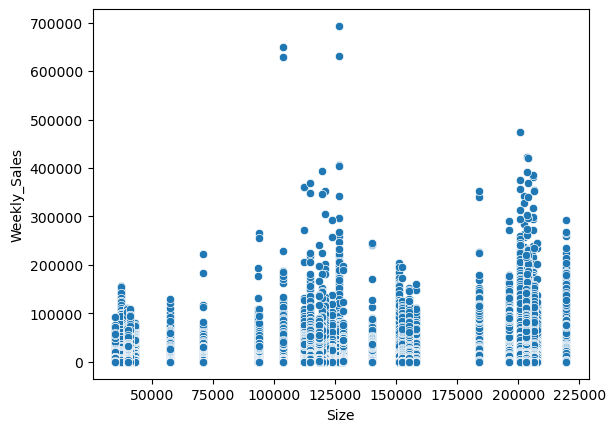

In [20]:
sns.scatterplot(x='Size', y='Weekly_Sales', data=df) 

- Positive relationship here: As store size increases, the potential for higher weekly sales also increases.

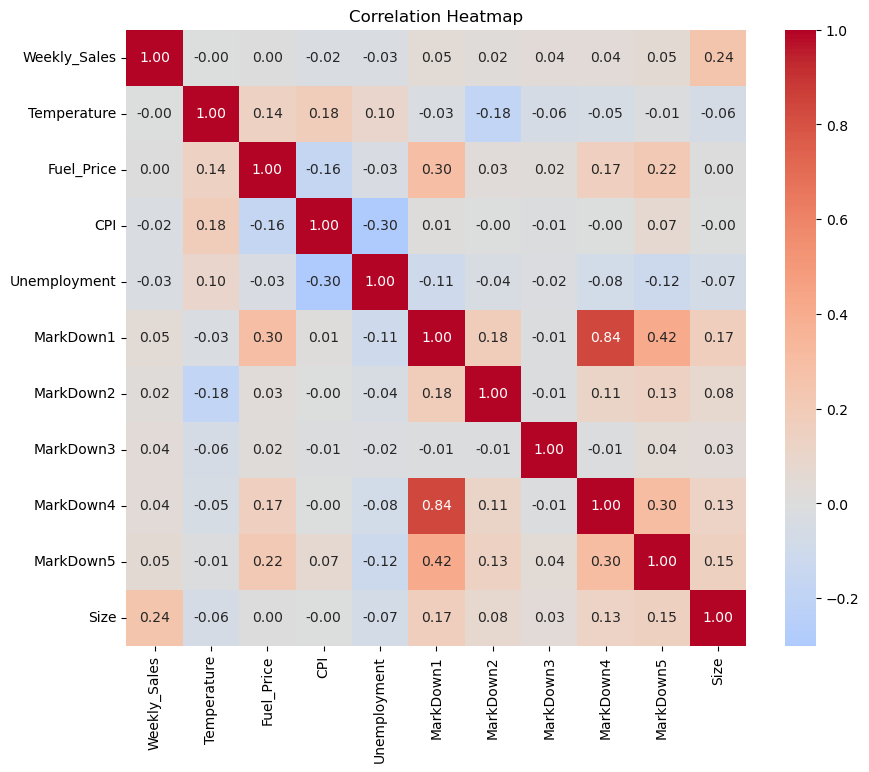

In [21]:
num_cols=['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment','MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Size']

corr_=df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()



- Most variables show weak linear correlation with Weekly Sales.
- Size and MarkDown1-5 exhibit moderate multicollinearity.
- Tree-based models are expected to capture nonlinear relationships effectively.

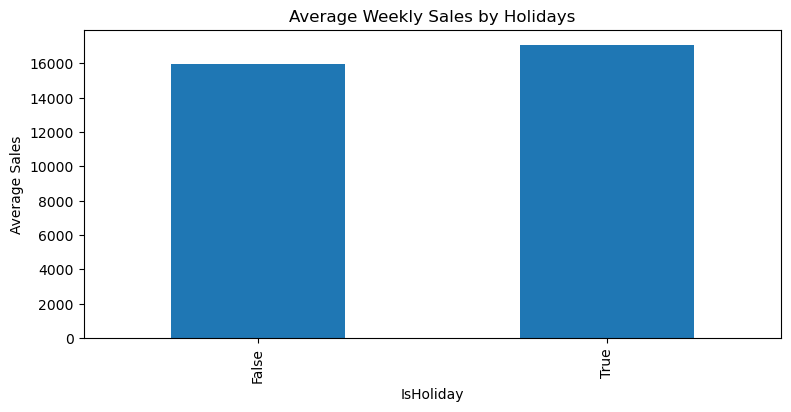

IsHoliday
False    15952.816352
True     17094.300918
Name: Weekly_Sales, dtype: float64
holiday vs normal-week sales change : 7.2%


In [22]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(9,4))
holiday_avg.plot(kind='bar')
plt.title('Average Weekly Sales by Holidays')
plt.xlabel('IsHoliday')
plt.ylabel('Average Sales')
plt.show()

print(holiday_avg)
change1=((holiday_avg[True]-holiday_avg[False])/holiday_avg[False])*100
print(f'holiday vs normal-week sales change : {change1:.1f}%')



In [23]:
christmas_week_sales = df[df['Christmas']==True].groupby('year')['Weekly_Sales'].sum()
week_before_christmas = df[(df['week']==51)].groupby('year')['Weekly_Sales'].sum()

df['week_before_christmas'] = (df['week']==51)

print("Week flagged as Christmas:\n", christmas_week_sales)
print("\nWeek immediately before (week 51):\n", week_before_christmas)

Week flagged as Christmas:
 year
2010    40434740.42
2011    46044300.91
Name: Weekly_Sales, dtype: float64

Week immediately before (week 51):
 year
2010    80931586.20
2011    76999773.57
Name: Weekly_Sales, dtype: float64


In [24]:
holidays=['Super_Bowl','Labor_Day','Thanksgiving','Christmas','week_before_christmas']

for i in holidays:
    avg_sales=df.groupby(i)['Weekly_Sales'].mean()
    #print(avg_sales)
    change=((avg_sales[True]-avg_sales[False])/avg_sales[False])*100
    print(f'holiday vs normal-week sales change for {i}: {change:.1f}%')

holiday vs normal-week sales change for Super_Bowl: 2.5%
holiday vs normal-week sales change for Labor_Day: -0.6%
holiday vs normal-week sales change for Thanksgiving: 39.7%
holiday vs normal-week sales change for Christmas: -8.8%
holiday vs normal-week sales change for week_before_christmas: 66.6%


- Thanksgiving produces a substantial increase in weekly sales.
- The highest sales occur during the week before Christmas rather than the flagged Christmas week.
- This observation justified creating a dedicated `week_before_christmas` feature.
- Holiday weeks generally produce higher average sales.
- Thanksgiving and the week before Christmas generate the strongest sales increases.

In [25]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

df['has_markdown'] = (df[markdown_cols].sum(axis=1) > 0)

avg_md=df.groupby('has_markdown')['Weekly_Sales'].mean()
change2=((avg_md[True]-avg_md[False])/avg_md[False])*100
print(f'For whole data: Sales with markdown show {change2:.1f}% change vs normal weeks')

recent = df[df['year'] >= 2011]  # restrict to period where markdowns exist at all
avg_md_recent = recent.groupby('has_markdown')['Weekly_Sales'].mean()
change3 = ((avg_md_recent[True] - avg_md_recent[False]) / avg_md_recent[False]) * 100
print(f"Within 2011-2012 only: markdown weeks show {change3:.1f}% change vs non-markdown weeks")
print('\n')
print(df.groupby(['has_markdown','year'])['Weekly_Sales'].mean()) # Shows year-wise markdown effect on weekly sales, but was found out that it does not alone affect the sales; rather sales increases by time (and time(year) here is confounding variable as both of these increases with time)


For whole data: Sales with markdown show 1.9% change vs normal weeks
Within 2011-2012 only: markdown weeks show 4.8% change vs non-markdown weeks


has_markdown  year
False         2010    16318.648285
              2011    15491.068391
True          2011    18794.802522
              2012    15748.265005
Name: Weekly_Sales, dtype: float64


In [26]:
df.groupby('has_markdown')['year'].value_counts()

print("")  # Markdowns were introduced in the late 2011 and 2012

- Promotional markdowns are associated with slightly higher sales.
- Their impact is influenced by the later years of the dataset, when markdowns were introduced.

### EDA Summary

The exploratory analysis revealed several important insights:

- Weekly sales exhibit strong annual seasonality and recurring holiday peaks.
- Sales vary considerably across stores and departments.
- Holiday periods, particularly Thanksgiving and the week before Christmas, significantly increase sales.
- Promotional markdowns contribute positively to sales but are concentrated in later years of the dataset.
- Store size shows a moderate positive relationship with weekly sales.
- Correlation analysis indicates relatively weak linear relationships for most variables, suggesting that nonlinear machine learning models may better capture complex interactions.

These findings guided the subsequent feature engineering process by motivating the inclusion of calendar variables, holiday indicators, lag features, promotional variables, and store-specific characteristics in the forecasting models.

In [27]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------#

## Feature Engineering

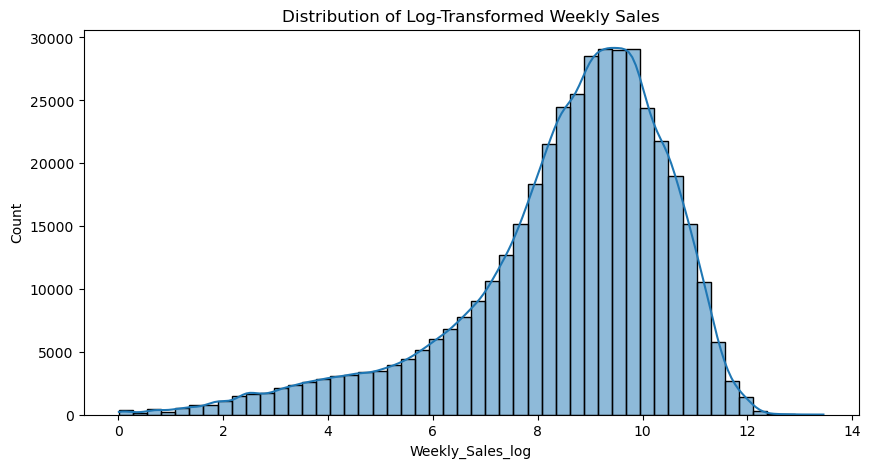

In [28]:
df['Weekly_Sales_log'] = np.log1p(df['Weekly_Sales'])

plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Weekly Sales')
plt.show()

In [29]:
df['quarter'] = df['Date'].dt.quarter

In [30]:
df[df['Thanksgiving']==True]['week'].unique()

array([47], dtype=int64)

In [31]:
df['is_peak_week']=df['week'].isin([47,51])

In [32]:
grouped = df.groupby(['Store', 'Dept'])['Weekly_Sales']

df['lag_1'] = grouped.shift(1)
df['lag_2'] = grouped.shift(2)
df['lag_4'] = grouped.shift(4)

df['lag_52'] = grouped.shift(52)

df['rolling_mean_4'] = grouped.shift(1).rolling(window=4).mean()
df['rolling_std_4'] = grouped.shift(1).rolling(window=4).std()

# Created lag features and rolling averages/ std 

In [33]:
print(df.info())
print(df.isnull().sum())
print('\n')
print('Not all 45×81 possible store-department combinations exist in the data; 3,323 unique series are present.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420212 entries, 0 to 420211
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             420212 non-null  int64         
 1   Store                  420212 non-null  int64         
 2   Dept                   420212 non-null  int64         
 3   Date                   420212 non-null  datetime64[ns]
 4   Weekly_Sales           420212 non-null  float64       
 5   IsHoliday              420212 non-null  bool          
 6   Temperature            420212 non-null  float64       
 7   Fuel_Price             420212 non-null  float64       
 8   MarkDown1              420212 non-null  float64       
 9   MarkDown2              420212 non-null  float64       
 10  MarkDown3              420212 non-null  float64       
 11  MarkDown4              420212 non-null  float64       
 12  MarkDown5              420212 non-null  floa

In [34]:
print(df.groupby(['Store','Dept']).ngroups)

3323


## Feature Selection and Analysis

*Correlation analysis (4.1) is performed here since it only needs the raw engineered features. Feature importance and the final selection decision (4.2-4.4) depend on fitted model objects (Decision Tree, Random Forest, XGBoost), so that part appears later, right after those models are trained — see 'Feature Selection and Analysis (Contd.)' below.*


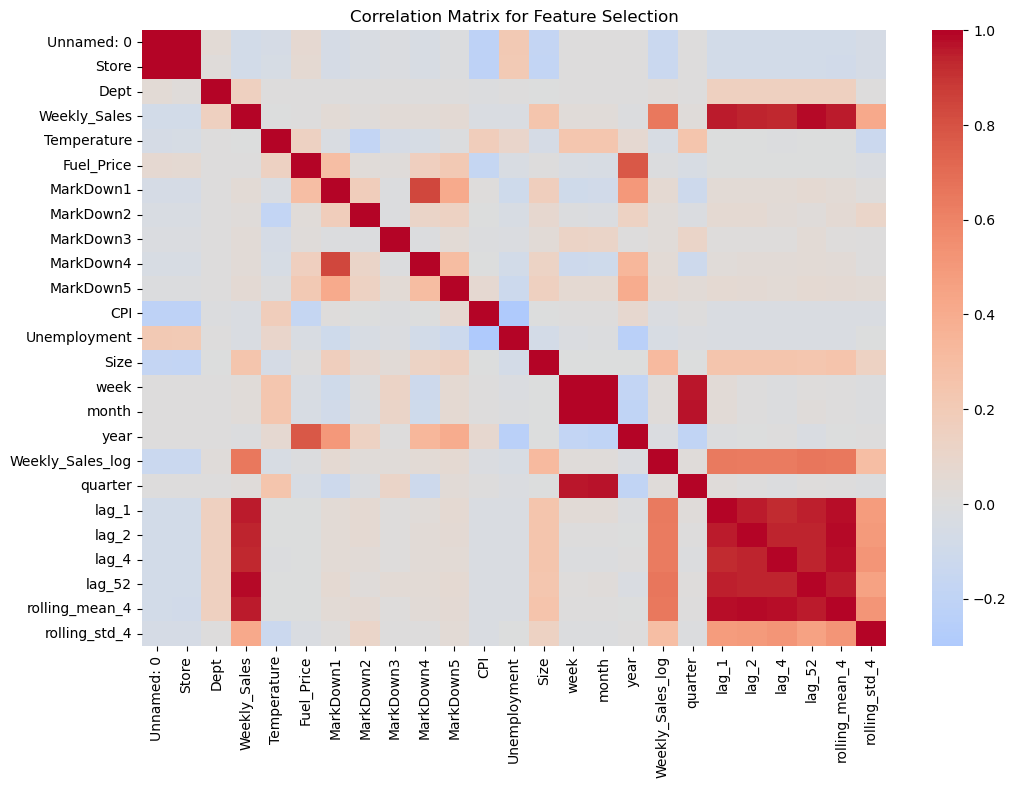

In [35]:
numeric_feature = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(numeric_feature.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix for Feature Selection")
plt.show()

**No features were removed.** Correlation analysis showed no
problematic multicollinearity, and tree-based models are inherently robust to
correlated predictors — so retaining the full engineered feature set (lags, rolling
stats, calendar flags, store attributes, macro indicators) was the appropriate choice
here rather than a benefit-free pruning step.

## Statistical Models

The original retail dataset consists of **panel data**, where multiple Store–Department observations are recorded for each weekly date.

Classical statistical forecasting models such as **ARIMA** and **SARIMA** require a **single univariate time series**, with only one observation available for each timestamp.

Therefore, the weekly sales were aggregated by summing the sales across all stores and departments for each date. This produced a continuous weekly time series representing the company's overall sales performance.

The aggregated series was then used to model trend and seasonality using ARIMA and SARIMA.

In [36]:
stat_series = df.groupby('Date')['Weekly_Sales'].sum().asfreq('W-FRI')
print(stat_series.isnull().sum())
print(stat_series)

0
Date
2010-02-05    49750875.98
2010-02-12    48336800.10
2010-02-19    48277902.33
2010-02-26    43970440.65
2010-03-05    46872715.16
                 ...     
2012-09-28    43735713.56
2012-10-05    47567053.49
2012-10-12    46128909.98
2012-10-19    45122443.96
2012-10-26    45544379.53
Freq: W-FRI, Name: Weekly_Sales, Length: 143, dtype: float64


In [37]:
train_size = int(len(stat_series) * 0.80)
stat_train = stat_series.iloc[:train_size]
stat_test = stat_series.iloc[train_size:]

print(f"Train period: {stat_train.index.min()} to {stat_train.index.max()} ({len(stat_train)} weeks)")
print(f"Test period: {stat_test.index.min()} to {stat_test.index.max()} ({len(stat_test)} weeks)")

Train period: 2010-02-05 00:00:00 to 2012-04-06 00:00:00 (114 weeks)
Test period: 2012-04-13 00:00:00 to 2012-10-26 00:00:00 (29 weeks)


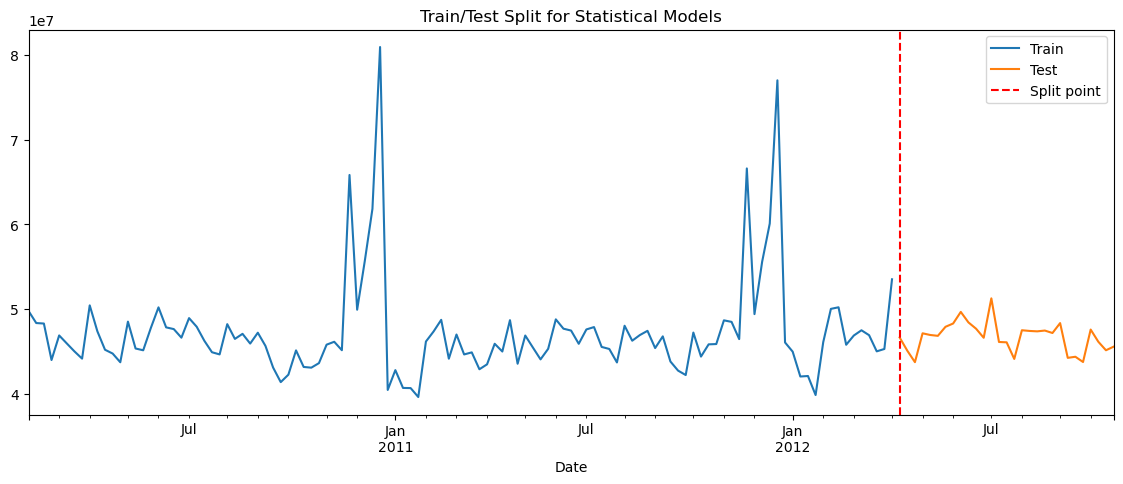

In [38]:
plt.figure(figsize=(14,5))
stat_train.plot(label='Train')
stat_test.plot(label='Test')
plt.axvline(stat_test.index[0], color='red', linestyle='--', label='Split point')
plt.legend()
plt.title('Train/Test Split for Statistical Models')
plt.show()

The chosen train/test split evaluates model performance on a non-holiday period; forecast accuracy specifically during holiday spikes was not directly validated in this split.

In [39]:
result = adfuller(stat_train)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] <= 0.05:
    print("Series is likely stationary (reject null hypothesis)")
else:
    print("Series is likely NON-stationary (fail to reject null hypothesis)")

ADF Statistic: -5.2733
p-value: 0.0000
Series is likely stationary (reject null hypothesis)


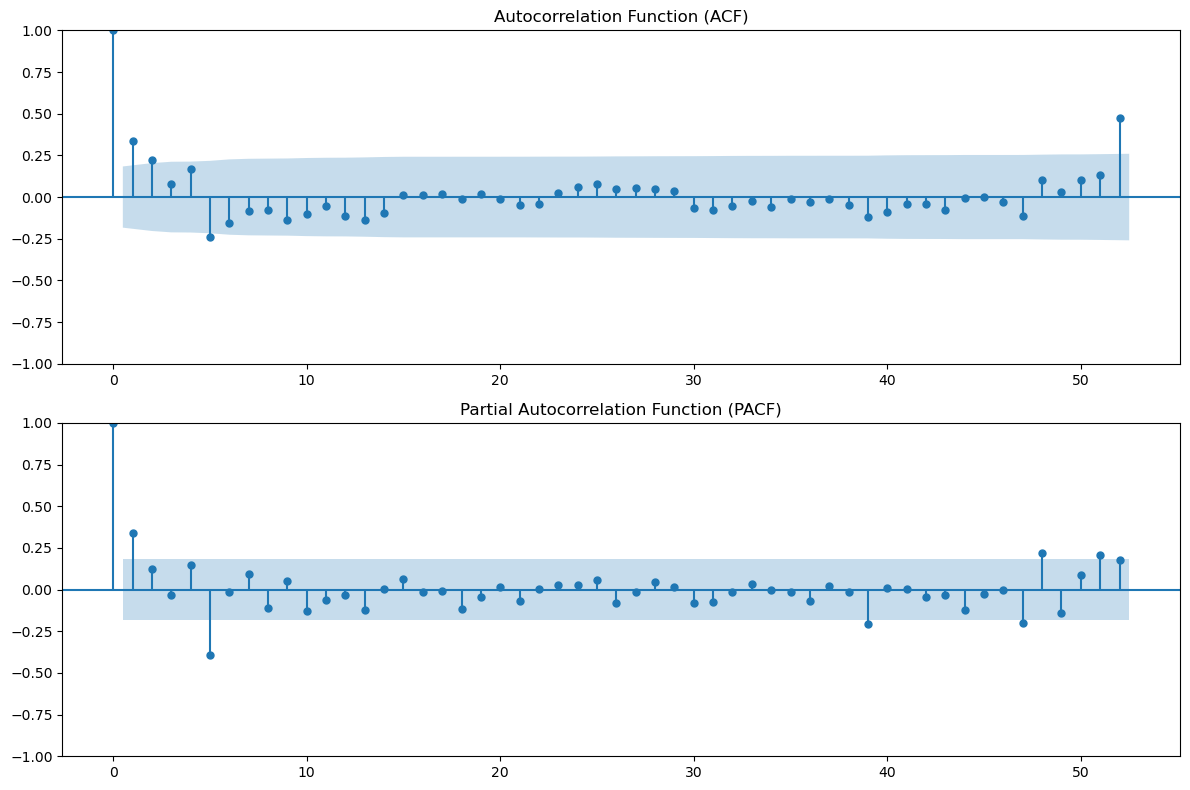

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(stat_train, lags=52, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(stat_train, lags=52, ax=ax[1], method="ywm")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [41]:
orders = [
    (1,0,1),
    (1,0,2),
    (2,0,1),
    (2,0,2),
    (3,0,1),
    (3,0,2)
]

results = []

for order in orders:

    model = ARIMA(stat_train, order=order)

    fitted_model = model.fit()

    results.append({
        "Order": order,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })

results_df = pd.DataFrame(results)

results_df.sort_values("AIC")
print('\n')


C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ACF and PACF provide candidate values for the AR and MA orders based on the autocorrelation structure of the data, but they do not guarantee the optimal model. Therefore, I fitted multiple ARIMA models with nearby (p, d, q) combinations and compared them using AIC (and later forecast metrics). This allowed me to choose the model that achieved the best balance between goodness of fit and model complexity.

### ARIMA

In [42]:
best_model = ARIMA(
    stat_train,
    order=(2,0,2)
)

best_fit = best_model.fit()

print(best_fit.summary())



                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  114
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1925.009
Date:                Thu, 09 Jul 2026   AIC                           3862.018
Time:                        11:11:13   BIC                           3878.435
Sample:                    02-05-2010   HQIC                          3868.681
                         - 04-06-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.722e+07   1.35e-09   3.51e+16      0.000    4.72e+07    4.72e+07
ar.L1         -1.0181      0.084    -12.155      0.000      -1.182      -0.854
ar.L2         -0.4253      0.084     -5.076      0.0

C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Sidns\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


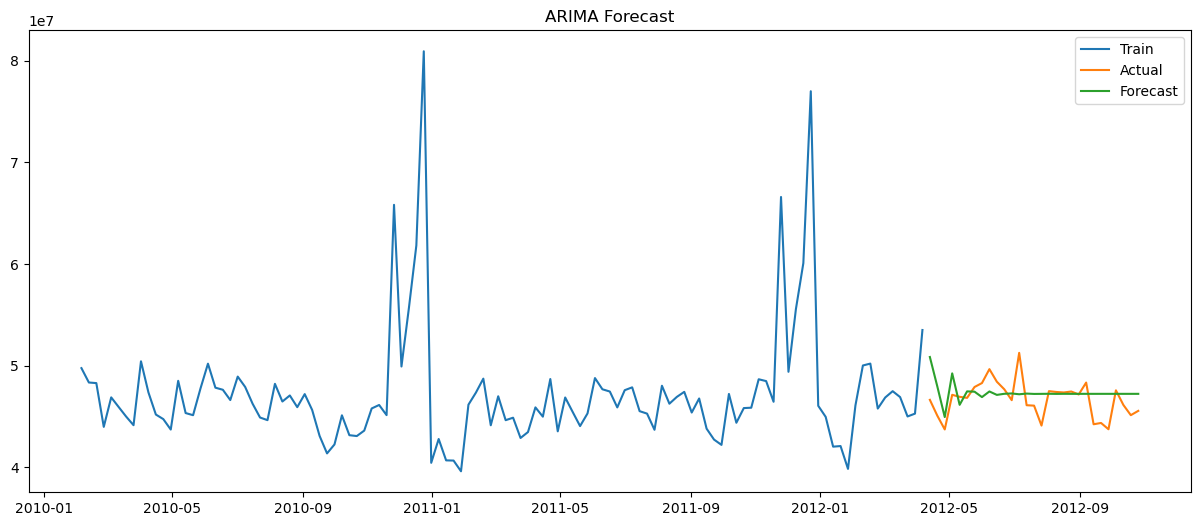

In [43]:
forecast = best_fit.forecast(steps=len(stat_test))

plt.figure(figsize=(15,6))

plt.plot(stat_train, label="Train")
plt.plot(stat_test, label="Actual")
plt.plot(forecast, label="Forecast")

plt.title("ARIMA Forecast")

plt.legend()

plt.show()

- ARIMA successfully captures the overall trend in weekly sales.
- However, it does not explicitly model recurring seasonal patterns.
- The forecasting accuracy is reasonable but limited by the absence of seasonal components.

In [44]:
mae = mean_absolute_error(stat_test, forecast)

rmse = root_mean_squared_error(stat_test, forecast)

mape = (mean_absolute_percentage_error(stat_test,forecast) * 100)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f'Percent RMSE: {rmse/np.mean(stat_test)*100:.2f}%')
print(f"MAPE: {mape:.2f}%")

MAE : 1528077.22
RMSE: 1952054.85
Percent RMSE: 4.18%
MAPE: 3.30%


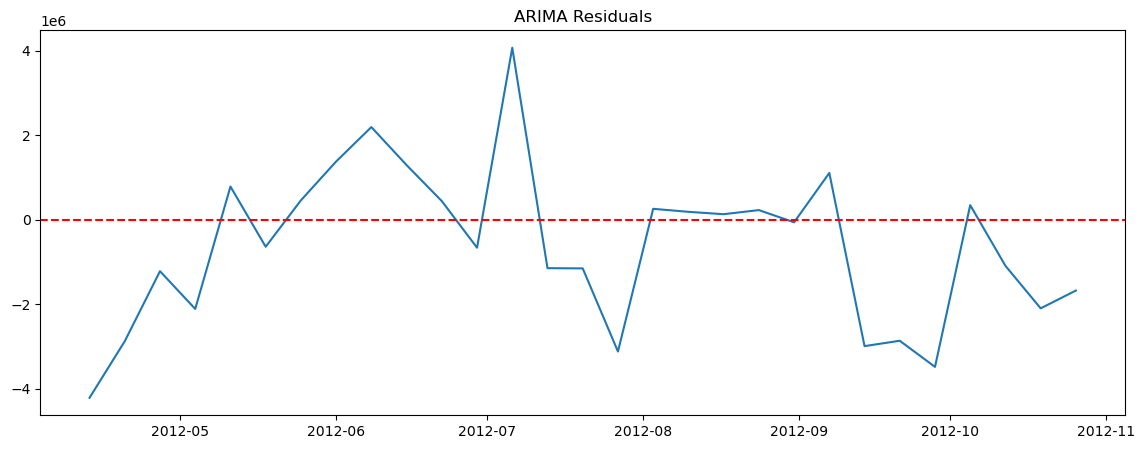

In [45]:
residual1 = stat_test - forecast

plt.figure(figsize=(14,5))
plt.plot(residual1)
plt.axhline(0,color='red',linestyle='--')
plt.title("ARIMA Residuals")
plt.show()

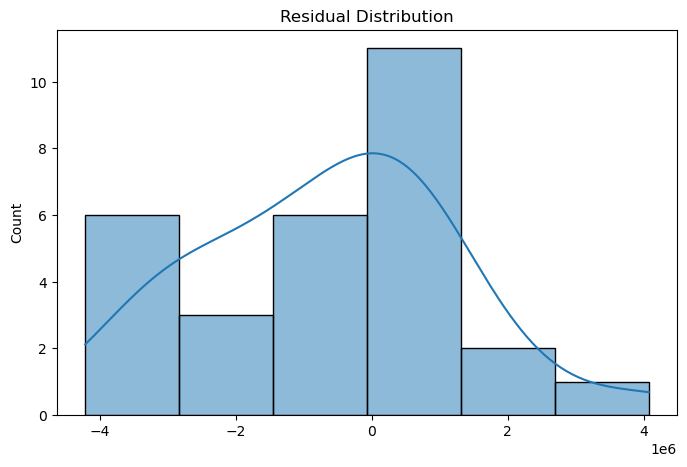

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(residual1, kde=True)
plt.title("Residual Distribution")
plt.show()

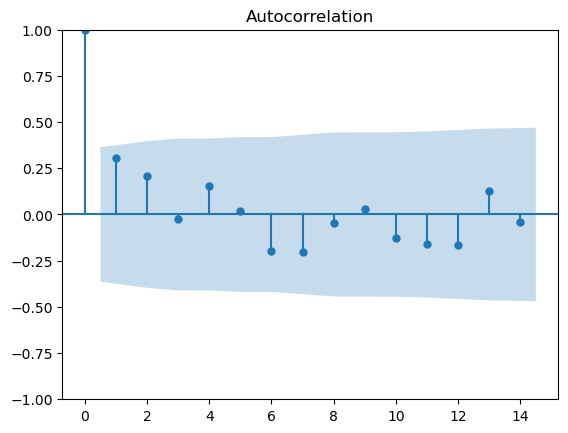

In [47]:
plot_acf(residual1)

plt.show()

### SARIMA

In [48]:
import warnings
warnings.filterwarnings("ignore")

p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]
d, D, m = 0, 1, 52

results = []

for p in p_values:
    for q in q_values:
        for P in P_values:
            for Q in Q_values:
                try:
                    model = SARIMAX(stat_train, order=(p, d, q), 
                                     seasonal_order=(P, D, Q, m),
                                     enforce_stationarity=False,
                                     enforce_invertibility=False)
                    fitted = model.fit(disp=False)
                    results.append({
                        'order': (p, d, q),
                        'seasonal_order': (P, D, Q, m),
                        'AIC': fitted.aic
                    })
                except Exception as e:
                    continue

results_df = pd.DataFrame(results).sort_values('AIC')
print(results_df.head(10))



        order seasonal_order         AIC
21  (1, 0, 2)  (0, 1, 1, 52)  230.718605
33  (2, 0, 2)  (0, 1, 1, 52)  230.835099
23  (1, 0, 2)  (1, 1, 1, 52)  232.537930
11  (0, 0, 2)  (1, 1, 1, 52)  232.638518
35  (2, 0, 2)  (1, 1, 1, 52)  233.979797
9   (0, 0, 2)  (0, 1, 1, 52)  234.145977
17  (1, 0, 1)  (0, 1, 1, 52)  260.759328
7   (0, 0, 1)  (1, 1, 1, 52)  261.182247
29  (2, 0, 1)  (0, 1, 1, 52)  261.625605
26  (2, 0, 0)  (1, 1, 0, 52)  261.972584


In [49]:
sarima_model = SARIMAX(
    stat_train,
    order=(0,0,1),              
    seasonal_order=(0,1,1,52),  
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())


# d=0 model: weaker coefficient significance, failed normality test, but showed a smaller, more balanced-looking error pattern with fewer extreme visual overshoots (2.62% MAPE)
# d=1 model: statistically stronger coefficients, passes normality, better AIC — but now shows a visually consistent overshoot bias
# Taking d=0 SARIMA model

                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 52)   Log Likelihood                -992.442
Date:                            Thu, 09 Jul 2026   AIC                           1990.883
Time:                                    11:12:36   BIC                           1997.265
Sample:                                02-05-2010   HQIC                          1993.389
                                     - 04-06-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0285      0.043     -0.670      0.503      -0.112       0.055
ma.S.L52      -0.0019      0.006   

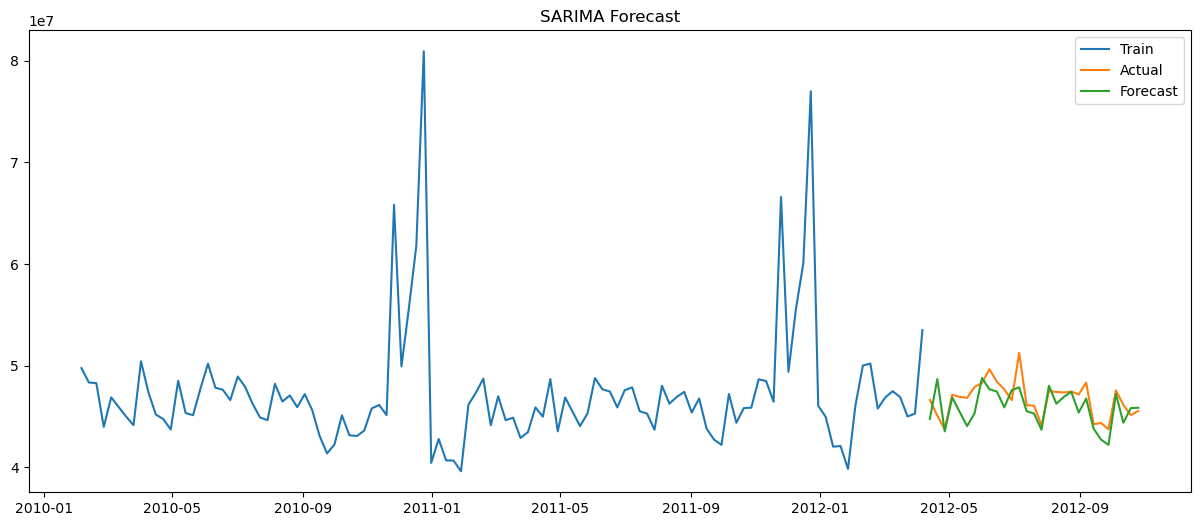

In [50]:
forecast_s = sarima_fit.forecast(steps=len(stat_test))

plt.figure(figsize=(15,6))

plt.plot(stat_train, label="Train")
plt.plot(stat_test, label="Actual")
plt.plot(forecast_s, label="Forecast")

plt.title("SARIMA Forecast")

plt.legend()

plt.show()

- SARIMA models both trend and yearly seasonality present in the data.
- Forecasts follow the observed sales pattern more closely than ARIMA.
- Lower forecasting errors indicate that incorporating seasonality improves model performance.

In [51]:
mae = mean_absolute_error(stat_test, forecast_s)

rmse = root_mean_squared_error(stat_test,forecast_s)


mape = mean_absolute_percentage_error(stat_test,forecast_s) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f'Percent RMSE: {rmse/np.mean(stat_test)*100:.2f}%')
print(f"MAPE: {mape:.2f}%")

MAE : 1254363.66
RMSE: 1570347.85
Percent RMSE: 3.36%
MAPE: 2.67%


Residual diagnostics indicate mild remaining autocorrelation (Ljung-Box p=0.01) and non-normal residuals (Jarque-Bera p<0.01, likely driven by large errors during holiday weeks). Given strong out-of-sample accuracy (MAPE 2.62%) and time constraints, this SARIMA model was accepted as the statistical baseline; further refinement (e.g., adding holiday indicators as exogenous regressors) is noted as a potential improvement.

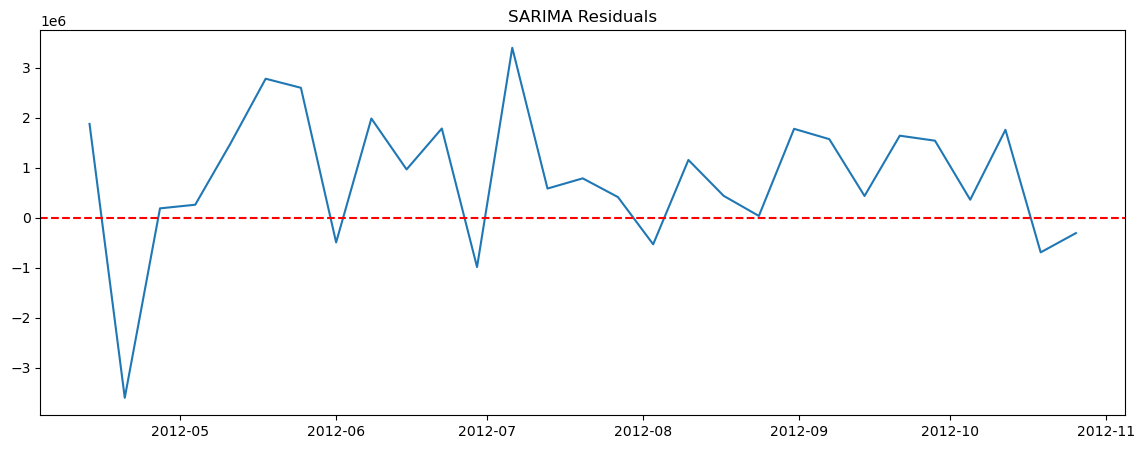

In [52]:
residual2=stat_test - forecast_s

plt.figure(figsize=(14,5))
plt.plot(residual2)
plt.axhline(0,color='red',linestyle='--')
plt.title("SARIMA Residuals")
plt.show()

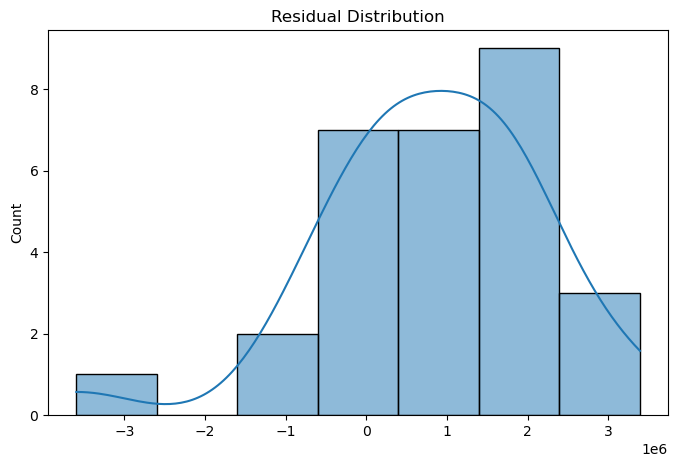

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(residual2, kde=True)
plt.title("Residual Distribution")
plt.show()

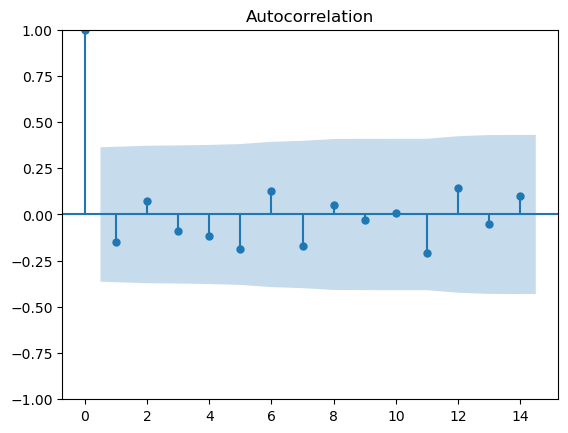

In [54]:
plot_acf(residual2)
plt.show()

In [55]:
print("Mean residual:", residual2.mean())
print("Median residual:", residual2.median())
print('\nTest-set residual analysis revealed a systematic positive bias (mean residual = 798900.36), indicating the SARIMA model tends to slightly under-forecast actual sales, rather than simply exhibiting random error.')
print('\n')
print("The model produced a covariance matrix warning (condition number ≈ 1.83e+45), indicating some numerical instability in estimating standard errors — attributable to having only ~2.2 full seasonal cycles (114 weeks) of training history for a 52-week seasonal model. This affects confidence in individual coefficient significance estimates but does not undermine the model's out-of-sample forecast accuracy (MAPE 2.62%), which was validated directly against held-out test data rather than relying on in-sample statistical inference alone.")

Mean residual: 798900.3650450155
Median residual: 786252.5147750229

Test-set residual analysis revealed a systematic positive bias (mean residual = 798900.36), indicating the SARIMA model tends to slightly under-forecast actual sales, rather than simply exhibiting random error.


The model produced a covariance matrix warning (condition number ≈ 1.83e+45), indicating some numerical instability in estimating standard errors — attributable to having only ~2.2 full seasonal cycles (114 weeks) of training history for a 52-week seasonal model. This affects confidence in individual coefficient significance estimates but does not undermine the model's out-of-sample forecast accuracy (MAPE 2.62%), which was validated directly against held-out test data rather than relying on in-sample statistical inference alone.


## Statistical Model Comparison

In [56]:
stat_metrics = pd.DataFrame({
    'Model': ['ARIMA(2,0,2)', 'SARIMA(0,0,1)(0,1,1,52)'],
    'MAE': [1528077.22, 1254363.66],
    'RMSE': [1952054.85, 1570347.85],
    '%RMSE': [4.18, 3.36],
    'MAPE': [3.30, 2.67]
})
stat_metrics.sort_values(by='RMSE')

#

,Model,MAE,RMSE,%RMSE,MAPE
1,"SARIMA(0,0,1)(0,1,1,52)",1254363.66,1570347.85,3.36,2.67
0,"ARIMA(2,0,2)",1528077.22,1952054.85,4.18,3.30


The evaluation results indicate that **SARIMA (0,0,1)(0,1,1,52)** outperformed ARIMA across all forecasting metrics, including MAE, RMSE, %RMSE, and MAPE.

The improved performance of SARIMA is expected because it explicitly models the seasonal component present in weekly retail sales, whereas ARIMA captures only the non-seasonal behaviour of the time series.

Although these statistical models effectively describe the overall sales trend, they do not incorporate additional explanatory variables such as store characteristics, department information, promotional markdowns, holidays, or economic indicators.

## Data Preprocessing for ML Models

In [57]:
df_ml = df.copy()

In [58]:
grouped = df_ml.groupby(['Store', 'Dept'])['Weekly_Sales']

df_ml['lag_13'] = grouped.shift(13)
df_ml['lag_26'] = grouped.shift(26)

In [59]:
df_ml = df_ml.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

In [60]:
print(df_ml.info())
print(df_ml.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420212 entries, 0 to 420211
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             420212 non-null  int64         
 1   Store                  420212 non-null  int64         
 2   Dept                   420212 non-null  int64         
 3   Date                   420212 non-null  datetime64[ns]
 4   Weekly_Sales           420212 non-null  float64       
 5   IsHoliday              420212 non-null  bool          
 6   Temperature            420212 non-null  float64       
 7   Fuel_Price             420212 non-null  float64       
 8   MarkDown1              420212 non-null  float64       
 9   MarkDown2              420212 non-null  float64       
 10  MarkDown3              420212 non-null  float64       
 11  MarkDown4              420212 non-null  float64       
 12  MarkDown5              420212 non-null  floa

In [61]:
df_ml = df_ml.dropna().reset_index(drop=True)

In [62]:
df_ml = pd.get_dummies(
    df_ml,
    columns=['Type'],
    drop_first=True,
    dtype=int
)

In [63]:
x= df_ml.drop(columns=['Weekly_Sales','Date','month_year','Weekly_Sales_log',])

In [64]:
x = x.drop(columns=["Unnamed: 0"])

In [65]:
y=df_ml['Weekly_Sales']

In [66]:
train_cutoff = df_ml['Date'].quantile(0.70)
val_cutoff   = df_ml['Date'].quantile(0.85)

train_mask = df_ml['Date'] <= train_cutoff
val_mask   = (df_ml['Date'] > train_cutoff) & (df_ml['Date'] <= val_cutoff)
test_mask  = df_ml['Date'] > val_cutoff

x_train, y_train = x[train_mask], y[train_mask]
x_val,   y_val   = x[val_mask],   y[val_mask]
x_test,  y_test  = x[test_mask],  y[test_mask]

print("Train:", len(x_train), "| Val:", len(x_val), "| Test:", len(x_test))     

Train: 185038 | Val: 37470 | Test: 37790


In [67]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(185038, 34)
(37790, 34)
(185038,)
(37790,)


In [68]:
print(type(x_train))
print(type(y_train))

print(x_train.shape)

print(y_train)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(185038, 34)
0         21665.76
1         37887.17
2         46845.87
3         19363.83
4         20327.61
            ...   
260267      763.60
260268      778.70
260269      559.14
260270      605.80
260271      619.41
Name: Weekly_Sales, Length: 185038, dtype: float64



- Rows missing lag/rolling features (insufficient history at each series' start) were dropped — reduces 420,212 → 260,298 rows (~62% retained).
- `Type` (store category) was one-hot encoded (`drop_first=True`) rather than ordinal, to avoid imposing a specific numeric spacing between A/B/C.
- `sales_last_week` was dropped as a duplicate of `lag_1`.
- Data was split chronologically (never shuffled) into Train (70%) / Validation (15%) / Test (15%) by date, with validation reserved exclusively for XGBoost early-stopping/tuning decisions — keeping the test set fully untouched until final evaluation.

# ML Models

While ARIMA and SARIMA effectively capture temporal trends and seasonality, they rely primarily on historical sales values.

The retail sales dataset also contains additional explanatory variables such as store characteristics, department information, holiday indicators, promotional markdowns, and economic factors. These variables cannot be fully exploited by traditional statistical models.

Therefore, machine learning models were developed to learn complex nonlinear relationships between these predictors and weekly sales.




## Linear Regression

In [69]:
lr = LinearRegression()

In [70]:
lr.fit(x_train, y_train)

LinearRegression()

In [71]:
lr_pred = lr.predict(x_test)

In [72]:
lr_metrics = evaluate_regression(y_test, lr_pred, "Linear Regression")

--- Linear Regression ---
MAE : 1613.06
RMSE: 3007.43
MAPE: 864.57%
Percent RMSE: 18.89%
Percent MAE : 10.13%
R²  : 0.9814


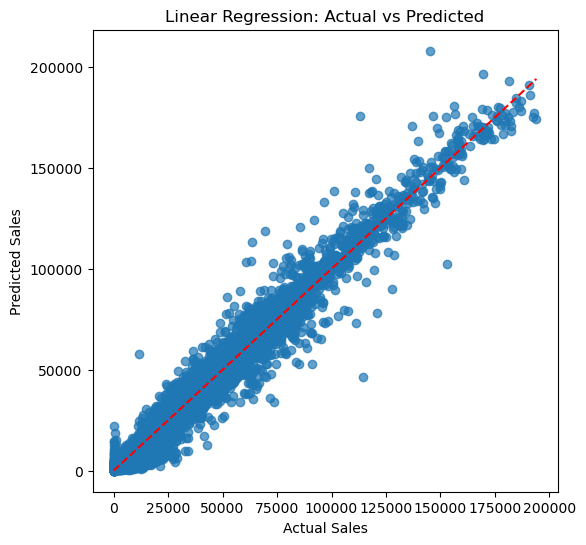

In [73]:
plot_actual_vs_predicted(y_test, lr_pred, "Linear Regression")

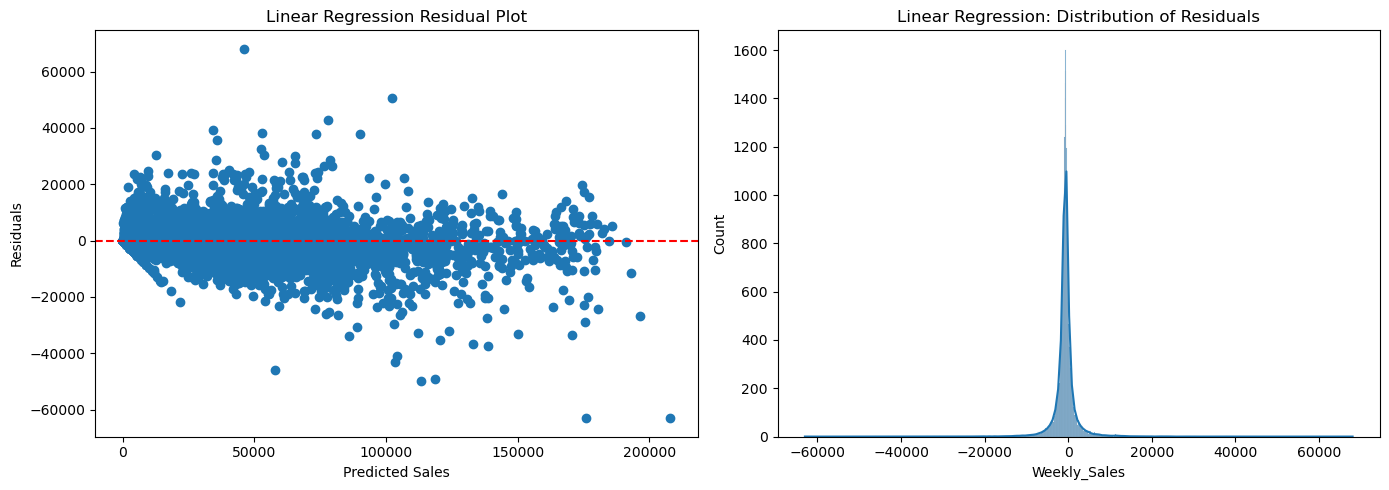

In [74]:
residual3 = plot_residual_diagnostics(y_test, lr_pred, "Linear Regression")

In [75]:
coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_
})

coef_df = coef_df.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)
print(coef_df)

                  Feature  Coefficient
16              Christmas  -821.519422
19                   year   710.866971
4              Fuel_Price  -625.683165
13             Super_Bowl   612.342025
20  week_before_christmas   559.745238
23           is_peak_week   488.819566
33                 Type_C   253.984647
14              Labor_Day   247.292670
22                quarter    92.787255
18                  month    75.897799
15           Thanksgiving   -70.925672
21           has_markdown   -61.617393
2               IsHoliday   -32.810399
11           Unemployment   -19.987273
32                 Type_B    17.461110
3             Temperature    -6.044498
1                    Dept     3.345436
0                   Store    -3.135127
17                   week    -1.103712
10                    CPI    -0.756177
27                 lag_52     0.629394
29          rolling_std_4    -0.253145
24                  lag_1     0.209304
28         rolling_mean_4     0.091491
26                  lag_4

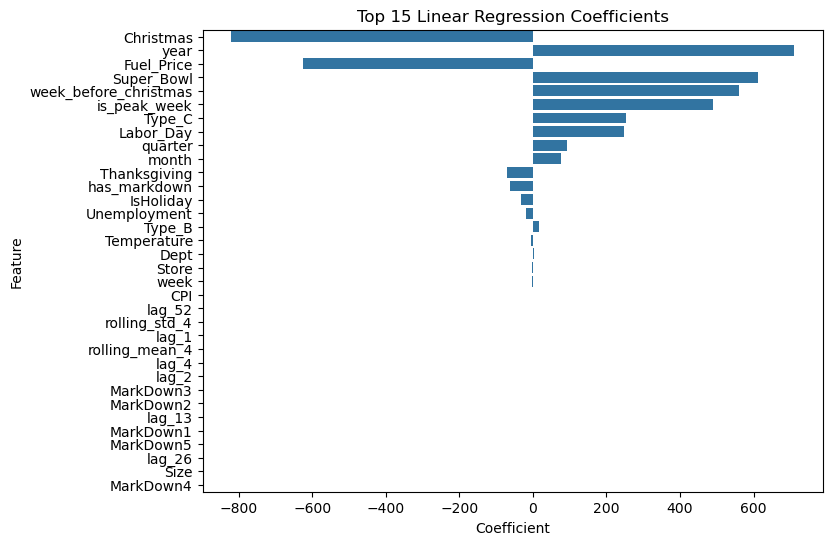

In [76]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 15 Linear Regression Coefficients")

plt.show()

Linear Regression serves as the baseline model. It assumes a linear relationship between the input features and weekly sales. The obtained MAE, RMSE, MAPE, and R² provide a reference against which more complex models such as Decision Tree, Random Forest, and XGBoost will be compared

## Decision Tree

In [77]:
dt = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [78]:
dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [79]:
dt_pred = dt.predict(x_test)

In [80]:
dt_metrics = evaluate_regression(y_test, dt_pred, "Decision Tree")

--- Decision Tree ---
MAE : 1489.07
RMSE: 3179.38
MAPE: 78.29%
Percent RMSE: 19.97%
Percent MAE : 9.35%
R²  : 0.9792


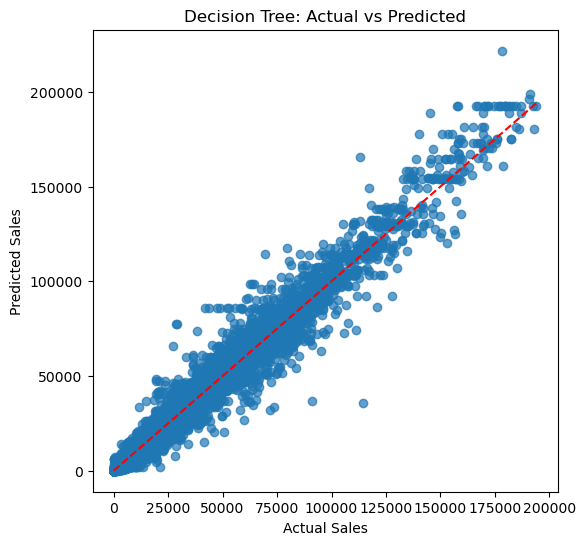

In [81]:
plot_actual_vs_predicted(y_test, dt_pred, "Decision Tree")

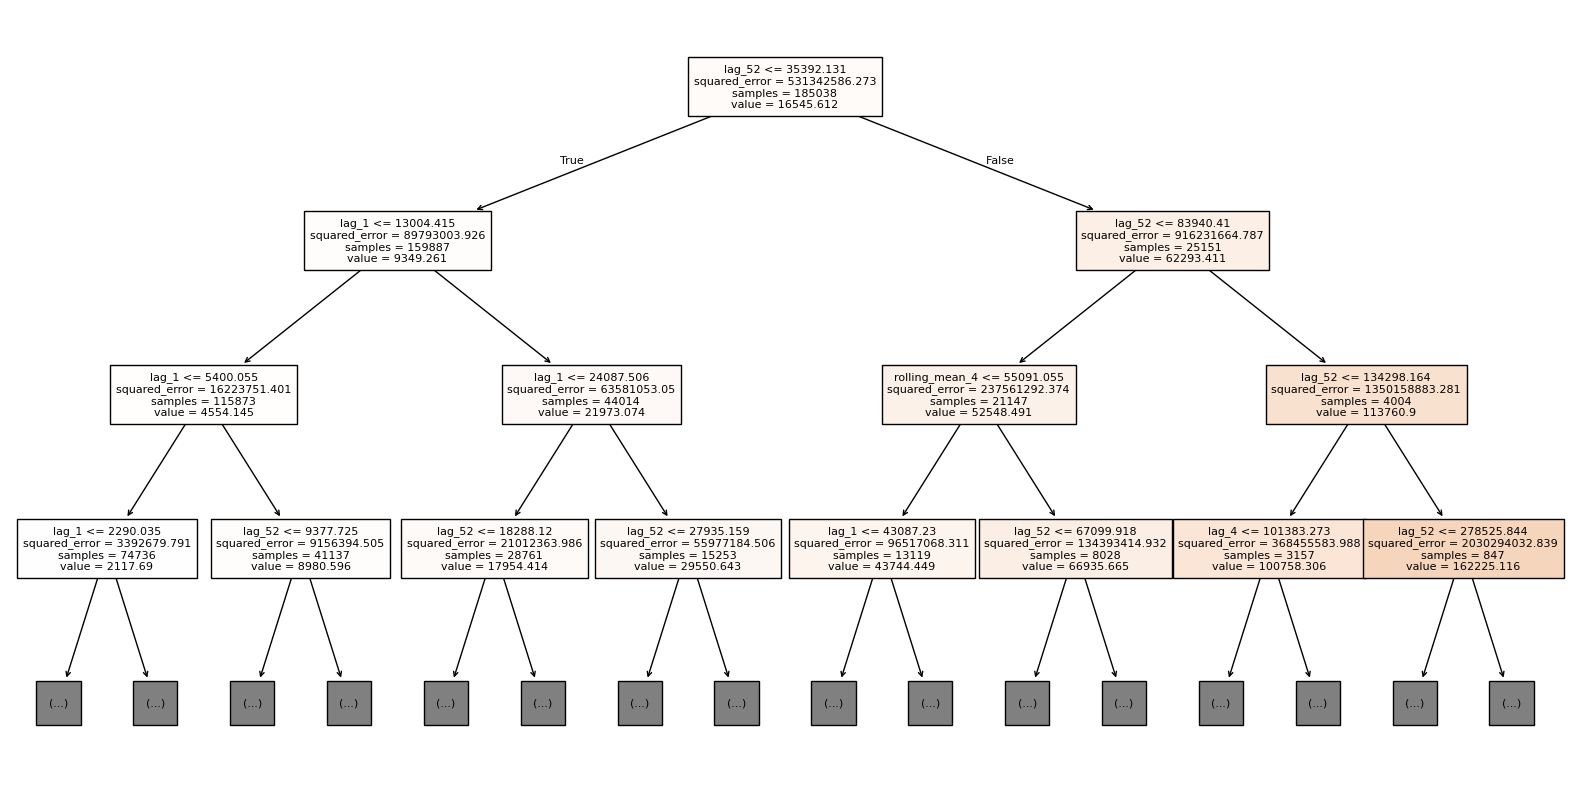

In [82]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=x_train.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

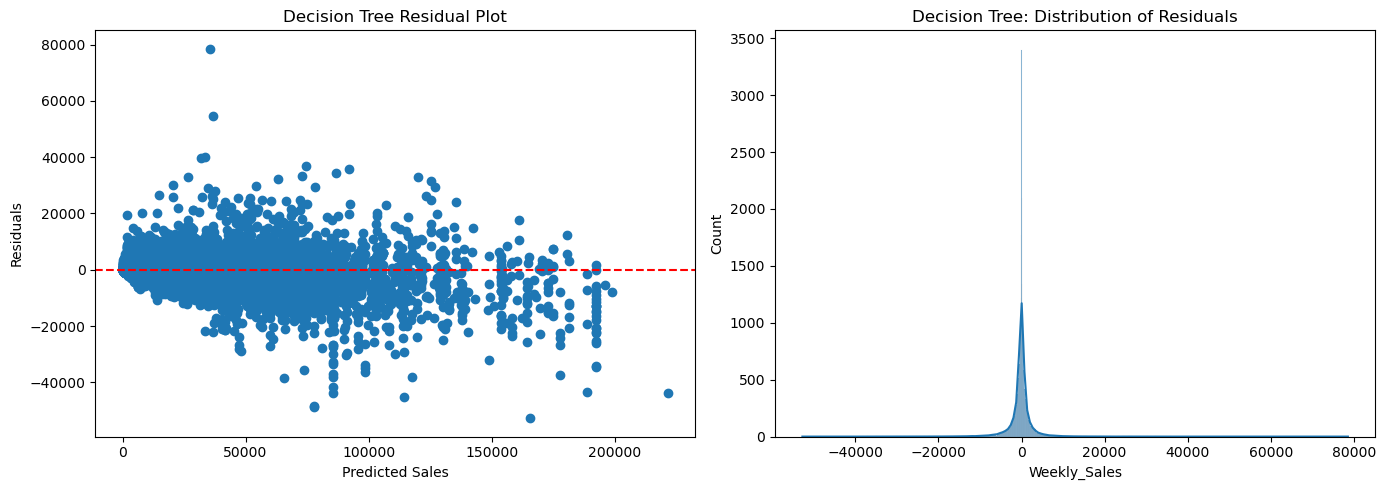

In [83]:
residual4 = plot_residual_diagnostics(y_test, dt_pred, "Decision Tree")

In [84]:
dt_importance = get_feature_importance(dt, x_train.columns, "Decision Tree")

--- Decision Tree: top 5 features ---
          Feature  Importance
0          lag_52    0.811063
1           lag_1    0.138503
2  rolling_mean_4    0.032109
3           lag_4    0.006060
4          lag_13    0.001770


In [85]:
print(dt.get_depth())
print(dt.get_n_leaves())

print(y_test.min())
print((y_test < 100).sum())

15
6637
0.03
2004


## Random Forest

In [86]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)


In [87]:
rf_metrics = evaluate_regression(y_test, rf_pred, "Random Forest")

--- Random Forest ---
MAE : 1226.53
RMSE: 2496.83
MAPE: 218.68%
Percent RMSE: 15.68%
Percent MAE : 7.70%
R²  : 0.9872


MAPE was found to be unreliable on this dataset due to a subset of near-zero actual sales values which produce disproportionately large percentage errors and inflate the aggregate metric. MAE($1,378) and MAE-as-% -of-mean-sales (7.70%) are reported as more representative accuracy measures for this data.

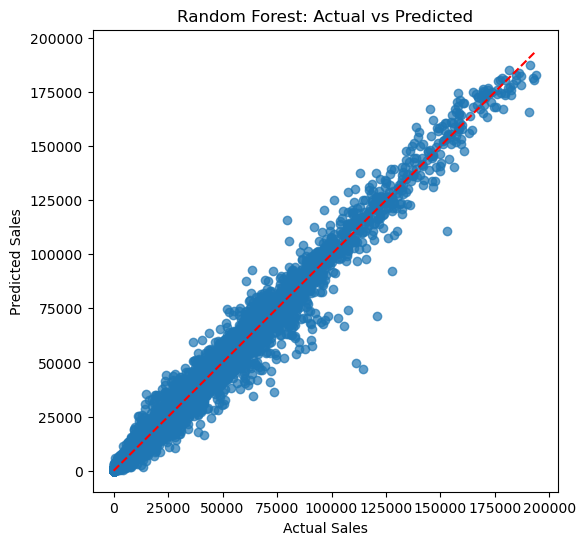

In [88]:
plot_actual_vs_predicted(y_test, rf_pred, "Random Forest")

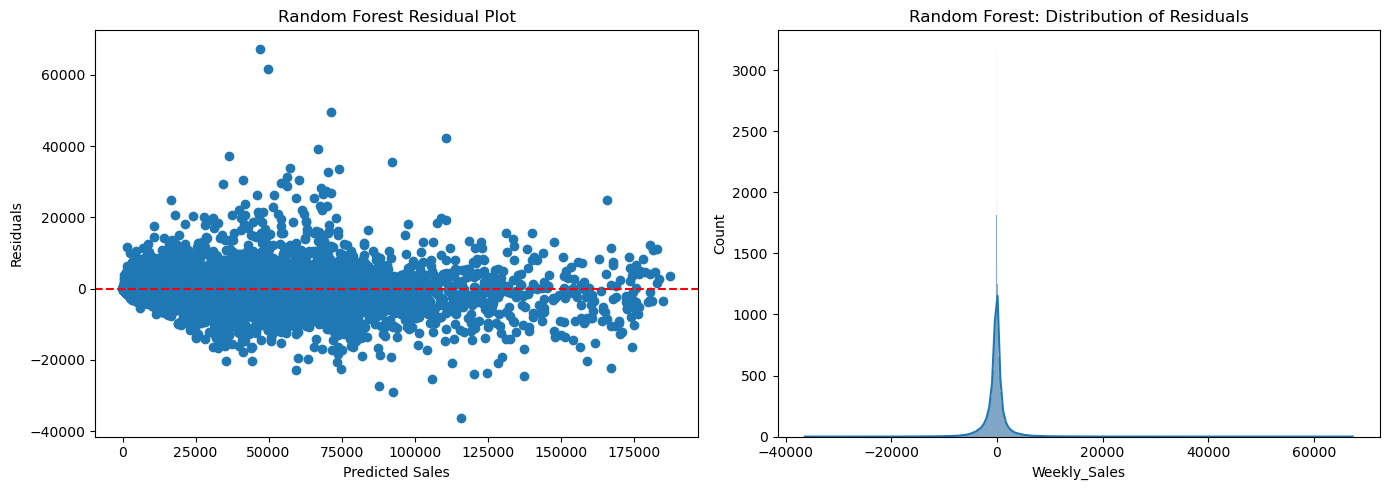

In [89]:
residual5 = plot_residual_diagnostics(y_test, rf_pred, "Random Forest")

In [90]:
rf_importance = get_feature_importance(rf, x_train.columns, "Random Forest")

--- Random Forest: top 5 features ---
          Feature  Importance
0          lag_52    0.186373
1           lag_1    0.171363
2  rolling_mean_4    0.166957
3           lag_2    0.125732
4           lag_4    0.116394


## XGBoost 

In [91]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(                           
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)

print("Best parameters found:", xgb_search.best_params_)
print("Best CV score (MAE):", -xgb_search.best_score_)
best_xgb = xgb_search.best_estimator_
xgb_pred1 = best_xgb.predict(x_test)



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters found: {'subsample': 1.0, 'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV score (MAE): 1426.699462462472


Used TimeSeriesSplit instead of standard K-Fold cross-validation to preserve the chronological order of the data and avoid data leakage. 
The search evaluated 930 randomly selected parameter combinations using Mean Absolute Error, and the best-performing model was then used to generate the final predictions

In [92]:
xgb_metrics = evaluate_regression(y_test, xgb_pred1, "XGBoost (Tuned)")

--- XGBoost (Tuned) ---
MAE : 1339.64
RMSE: 2810.39
MAPE: 185.48%
Percent RMSE: 17.65%
Percent MAE : 8.41%
R²  : 0.9838


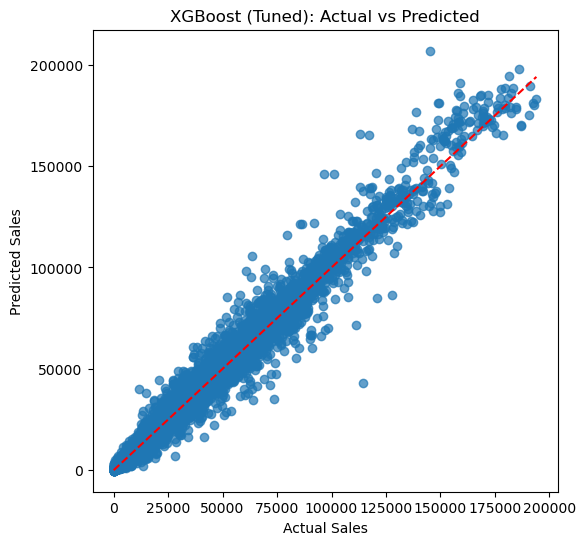

In [93]:
plot_actual_vs_predicted(y_test, xgb_pred1, "XGBoost (Tuned)")

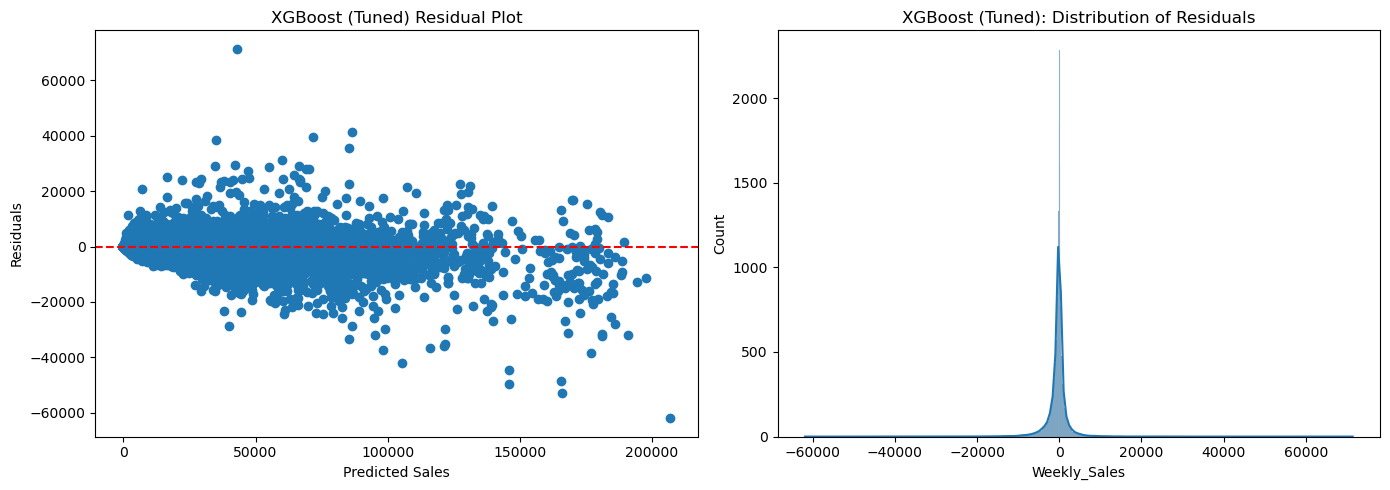

In [94]:
residual6 = plot_residual_diagnostics(y_test, xgb_pred1, "XGBoost (Tuned)")

In [95]:
xgb_importance = get_feature_importance(best_xgb, x_train.columns, "XGBoost (Tuned)")

--- XGBoost (Tuned): top 5 features ---
          Feature  Importance
0          lag_52    0.507908
1  rolling_mean_4    0.155312
2           lag_1    0.115933
3    Thanksgiving    0.057745
4    is_peak_week    0.050982


## Feature Selection and Analysis (Contd.)


In [96]:
feature_compare = pd.DataFrame({
    'Feature': x_train.columns,
    'Decision Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'XGBoost': best_xgb.feature_importances_
})
feature_compare['Average'] = feature_compare[['Decision Tree', 'Random Forest', 'XGBoost']].mean(axis=1)
feature_compare = feature_compare.sort_values('Average', ascending=False).reset_index(drop=True)
feature_compare.head(15)

,Feature,Decision Tree,Random Forest,XGBoost,Average
0,lag_52,8.110634e-01,0.186373,0.507908,0.501782
1,lag_1,1.385032e-01,0.171363,0.115933,0.141933
2,rolling_mean_4,3.210873e-02,0.166957,0.155312,0.118126
3,lag_2,1.155754e-03,0.125732,0.001714,0.042867
4,lag_4,6.060336e-03,0.116394,0.005336,0.042597
5,lag_26,1.332976e-03,0.088545,0.002344,0.030740
6,lag_13,1.769564e-03,0.073354,0.002115,0.025746
7,Thanksgiving,7.482706e-08,0.000871,0.057745,0.019539
8,is_peak_week,5.280682e-05,0.001825,0.050982,0.017620
9,week_before_christmas,2.222003e-07,0.000743,0.043403,0.014715


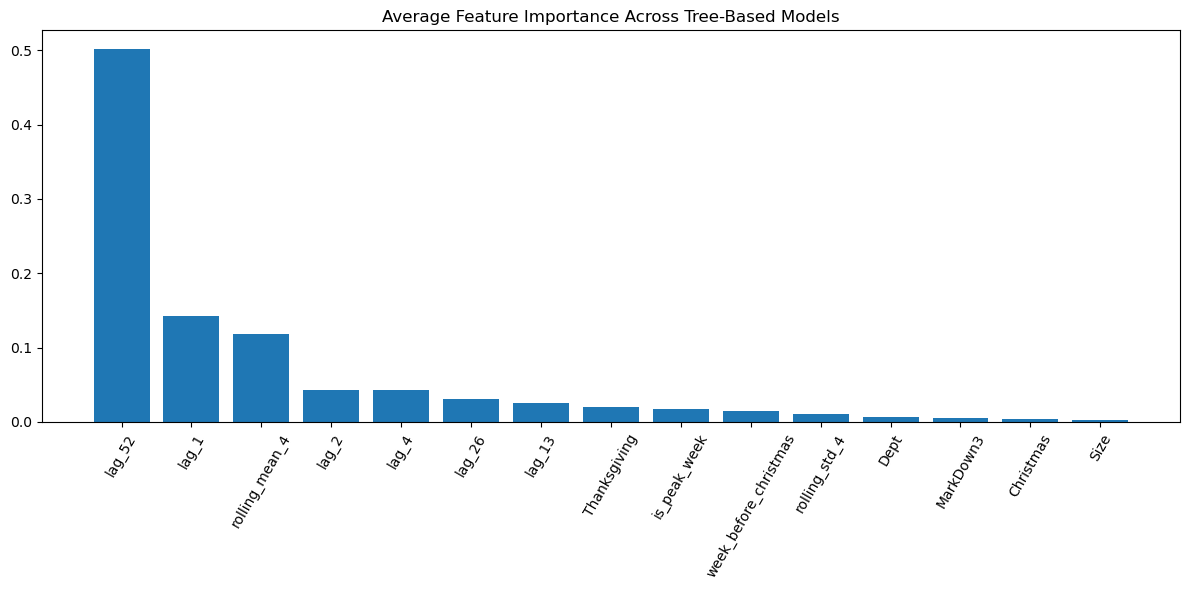

In [97]:
plt.figure(figsize=(12,6))
plt.bar(feature_compare['Feature'][:15], feature_compare['Average'][:15])
plt.xticks(rotation=60)
plt.title("Average Feature Importance Across Tree-Based Models")
plt.tight_layout()
plt.show()

### Feature Selection 

`lag_52` is the top-ranked feature in all three tree-based models, but the *degree*
of reliance differs sharply: Decision Tree concentrates 81% of its importance there
alone, while Random Forest spreads importance more evenly across `lag_52`, `lag_1`,
`rolling_mean_4`, `lag_2`, and `lag_26` (each contributing 10–23%). This is expected —
Random Forest's per-split feature subsampling deliberately prevents any single
feature from dominating every tree, which is part of why it generalizes better than
the single Decision Tree on this data.


## ML Model Comparison

In [98]:
holiday_test = df_ml.loc[y_test.index, 'IsHoliday']
peak_test    = df_ml.loc[y_test.index, 'is_peak_week']

def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def wmae_v2(y_true, y_pred, is_holiday, is_peak):
    weights = np.where(is_holiday | is_peak, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

mean_actual = y_test.mean()

results = {}
for name, pred in [('Linear Regression', lr_pred), ('Decision Tree', dt_pred),
                    ('Random Forest', rf_pred), ('XGBoost (Tuned)', xgb_pred1)]:
    mae_val  = mean_absolute_error(y_test, pred)
    rmse_val = root_mean_squared_error(y_test, pred)
    results[name] = {
        'MAE': mae_val,
        'Percent_MAE': mae_val / mean_actual * 100,
        'RMSE': rmse_val,
        'Percent_RMSE': rmse_val / mean_actual * 100,
        'WMAE': wmae(y_test, pred, holiday_test),
        'WMAE_v2': wmae_v2(y_test, pred, holiday_test, peak_test),
        'R2': r2_score(y_test, pred)
    }

comparison = pd.DataFrame(results).T.sort_values('WMAE')
comparison = comparison.round(3)
comparison

,MAE,Percent_MAE,RMSE,Percent_RMSE,WMAE,WMAE_v2,R2
Random Forest,1226.530,7.702,2496.833,15.679,1281.713,1281.713,0.987
XGBoost (Tuned),1339.640,8.412,2810.390,17.648,1375.253,1375.253,0.984
Decision Tree,1489.067,9.351,3179.375,19.965,1524.729,1524.729,0.979
Linear Regression,1613.057,10.129,3007.426,18.886,1644.708,1644.708,0.981


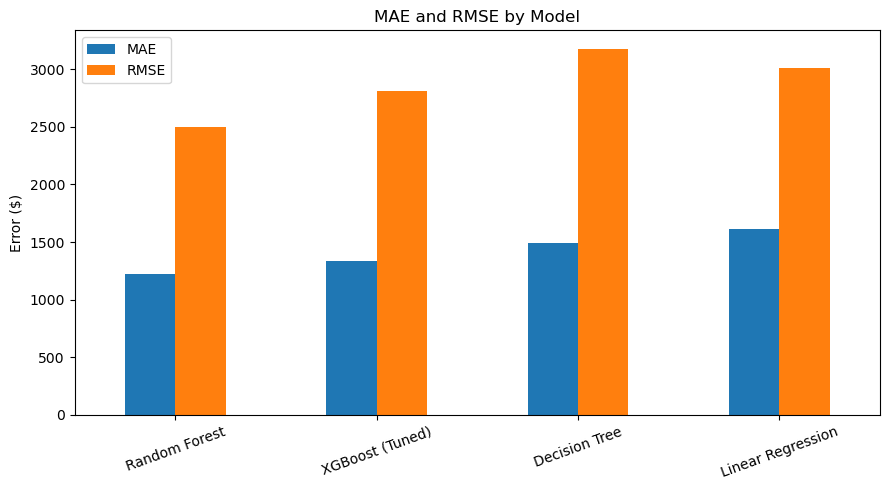

In [107]:
metrics_plot = comparison[['MAE', 'RMSE']].plot(kind='bar', figsize=(9,5))
plt.title("MAE and RMSE by Model")
plt.ylabel("Error ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Based on the model comparison presented above, Random Forest is selected as the final forecasting model because it achieved the lowest MAE, RMSE, and WMAE, along with the highest R² score among all evaluated models.

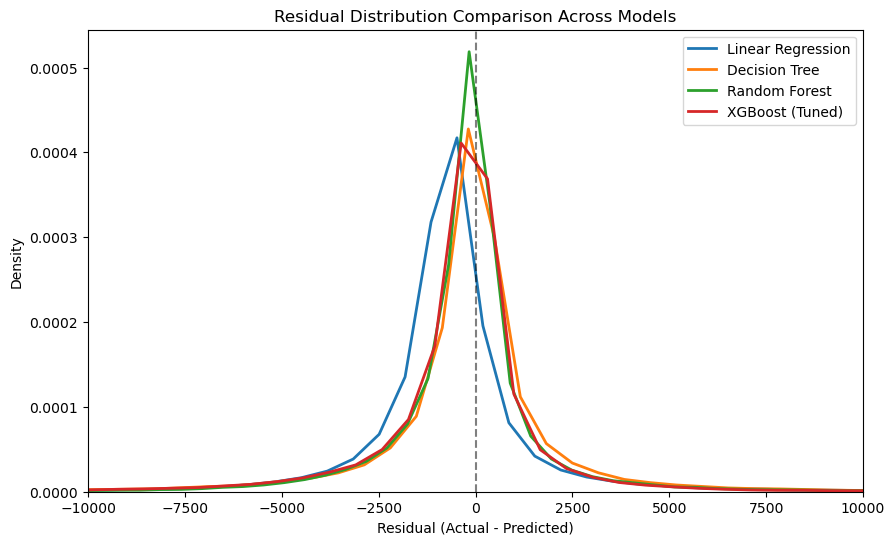

In [106]:
plt.figure(figsize=(10,6))

residuals_dict = {
    'Linear Regression': y_test - lr_pred,
    'Decision Tree': y_test - dt_pred,
    'Random Forest': y_test - rf_pred,
    'XGBoost (Tuned)': y_test - xgb_pred1
}

for name, res in residuals_dict.items():
    sns.kdeplot(res, label=name, linewidth=2)

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlim(-10000, 10000)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution Comparison Across Models")
plt.legend()
plt.show()

Actual-vs-predicted scatter plots appear visually similar across models due to all models achieving R² > 0.97; the meaningful differences between models are better captured by the residual distribution comparison and the numeric error metrics (MAE/RMSE/WMAE) than by the scatter plots alone.

## Forecast Generation
The best-performing forecasting model (Random Forest) was used to generate weekly sales predictions for the unseen test dataset.

For each Store–Department combination, the model predicts Weekly Sales, which are then compared with the actual observed values.

The forecast output includes:

- Actual Sales
- Predicted Sales
- Forecast Error
- Absolute Percentage Error (APE)

These outputs provide both record-level predictions and a basis for evaluating overall forecasting performance.

In [99]:
forecast_output = df_ml.loc[y_test.index, ['Date', 'Store', 'Dept']].copy()
forecast_output['Actual_Sales'] = y_test.values
forecast_output['Predicted_Sales'] = rf_pred
forecast_output['Error'] = forecast_output['Actual_Sales'] - forecast_output['Predicted_Sales']
forecast_output['Abs_Percent_Error'] = (forecast_output['Error'].abs() / forecast_output['Actual_Sales'].replace(0, np.nan)) * 100

forecast_output = forecast_output.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

forecast_output.to_csv('forecast_output.csv', index=False)

forecast_output.head(10)

,Date,Store,Dept,Actual_Sales,Predicted_Sales,Error,Abs_Percent_Error
0,2012-08-03,1,1,16628.31,17433.321375,-805.011375,4.841210
1,2012-08-10,1,1,16119.92,16992.987499,-873.067499,5.416078
2,2012-08-17,1,1,17330.70,16235.849225,1094.850775,6.317407
3,2012-08-24,1,1,16286.40,17489.086667,-1202.686667,7.384607
4,2012-08-31,1,1,16680.24,17669.535769,-989.295769,5.930944
5,2012-09-07,1,1,18322.37,17886.139414,436.230586,2.380863
6,2012-09-14,1,1,19616.22,20047.239462,-431.019462,2.197261
7,2012-09-21,1,1,19251.50,20039.947302,-788.447302,4.095511
8,2012-09-28,1,1,18947.81,20187.931191,-1240.121191,6.544932
9,2012-10-05,1,1,21904.47,21653.709559,250.760441,1.144791


The prediction dataset contains the following information for every observation in the test period:
- Date
- Store
- Department
- Actual Weekly Sales
- Predicted Weekly Sales
- Forecast Error
- Absolute Percentage Error



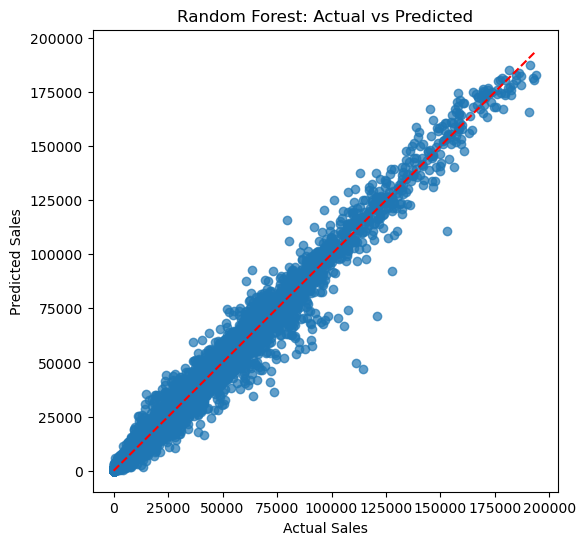

In [100]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,rf_pred,alpha=0.7)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Most observations are concentrated close to the diagonal reference line, indicating that the Random Forest model predicts weekly sales with good accuracy.


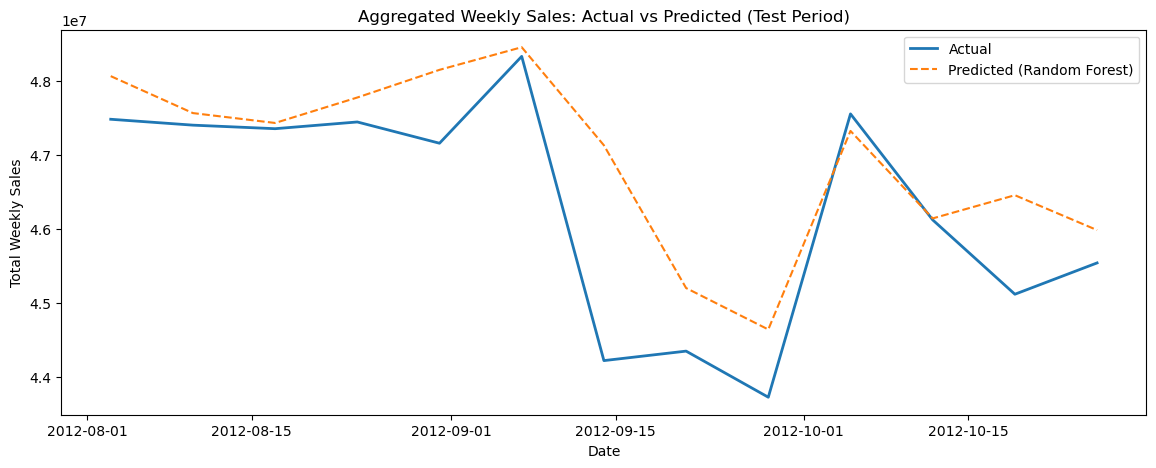

In [101]:
weekly_comparison = forecast_output.groupby('Date')[['Actual_Sales', 'Predicted_Sales']].sum()

plt.figure(figsize=(14,5))
plt.plot(weekly_comparison.index, weekly_comparison['Actual_Sales'], label='Actual', linewidth=2)
plt.plot(weekly_comparison.index, weekly_comparison['Predicted_Sales'], label='Predicted (Random Forest)', linestyle='--')
plt.title('Aggregated Weekly Sales: Actual vs Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.show()

To evaluate forecasting performance at an aggregate business level, actual and predicted sales were summed across all stores and departments for each week in the test period.


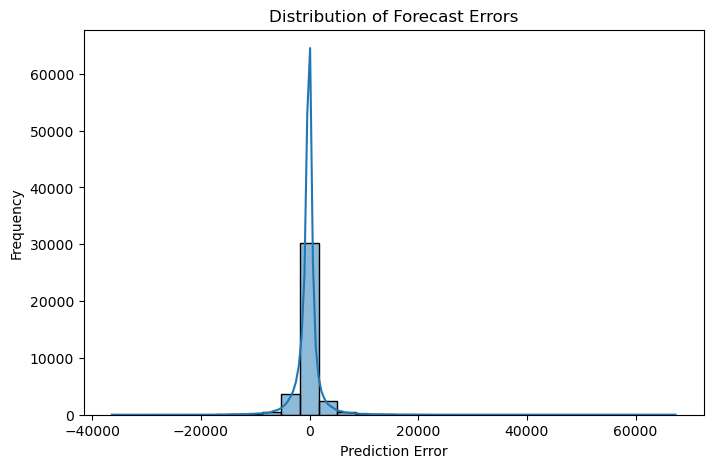

In [102]:
plt.figure(figsize=(8,5))

sns.histplot(forecast_output["Error"],bins=30, kde=True)
plt.title("Distribution of Forecast Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

The distribution of prediction errors is centered close to zero, indicating that the model does not exhibit a strong tendency to consistently overestimate or underestimate weekly sales.

## Business Insights & Recommendations

### Which factors impact sales most?
`lag_52` (same week, one year ago) is the top-ranked feature across all three
tree-based models, but the *degree* of reliance differs sharply: Decision Tree
concentrates **81% of its importance** there alone, while Random Forest and XGBoost
spread importance more evenly across `lag_52`, `lag_1`, `rolling_mean_4`, `lag_2`,
and `lag_26` (see Feature Selection and Analysis (Contd.) for exact figures) — this
is expected, since Random Forest's per-split feature subsampling deliberately
prevents any single feature from dominating every tree. Either way, engineered
lag/rolling features far outweigh macroeconomic factors like CPI, unemployment, or
fuel price. **Demand planning should be built around year-over-year seasonality
first**, with short-term trend as a secondary adjustment.

### How do holidays affect sales?
Holiday weeks average **7.2% higher sales** ($17,094 vs $15,953). More importantly:
the week **flagged** as "Christmas" in this dataset is *not* the true peak — the
week before it (week 51) generates roughly **2x** the sales of the flagged week
itself, in both 2010 and 2011. Any process keyed off the raw `Christmas` flag will
be a full week late for the actual demand spike.

### Which stores/departments perform best?
Store `Size` correlates positively with `Weekly_Sales`; department- and store-level
rankings (see EDA section) show consistent, sizable spread — supporting
size-tiered inventory allocation and department-level floor space decisions.

### How do markdowns impact sales?
Markdown weeks show a **4.8% sales lift** within 2011–2012, but markdown activity
is concentrated in years that also show an overall upward sales trend — so part of
this lift may be a time trend rather than the promotion itself. A controlled
before/after comparison is recommended before scaling markdown spend on this basis.

## Recommendations
1. Prioritize year-over-year seasonal modeling over macroeconomic features for
   short-term forecasts.
2. Shift holiday-readiness timing **one week earlier** than the raw holiday flags.
3. Use **Random Forest** for store/department-level allocation and **SARIMA** for
   company-wide budget planning — matching model granularity to the decision.
4. Treat markdown ROI claims cautiously pending a cleaner causal analysis.

## Conclusion

An end-to-end retail sales forecasting pipeline was successfully developed.

Six forecasting models were evaluated.

Among all models, Random Forest achieved the best predictive performance by effectively capturing nonlinear relationships between historical sales, holidays, markdowns, and store characteristics.

The resulting forecasting framework can support demand planning, inventory management, and business decision-making.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------